# Temporal Flexibility — Raw Data Insights


```
Earliest Pick-up              → earliest the rider can be picked up
Latest Pick-up Time           → latest the rider can be picked up
Scheduled Pick-up Arrival Time→ when the vehicle is actually scheduled
Requested Drop-off Time       → when the rider wants to arrive
Latest Drop-off Time          → latest acceptable arrival
Trip Date                     → calendar context
Purpose                       → trip reason (dialysis / medical / school / work / general)
Trip Status                   → Completed / Cancelled / No-Show
Cancel Time                   → when the cancellation happened
```

## Disclaimer: Some part of this code are enriched by Claude AI

** [e.g. drawing plots] **

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Parse Data

In [5]:
df = pd.read_csv("/Users/shives/Downloads/DOE_RFI/RFI-Rider_flexibility_index-/bjcta_para.csv")

In [8]:
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})
 

print('── Actual Purpose values in your data ──────────────────────')
print(df['Purpose'].value_counts(dropna=False).to_string())
 
print('\n── Actual Trip Status values in your data ──────────────────')
print(df['Trip Status'].value_counts(dropna=False).to_string())
 

PURPOSE_ORDER = (
    df['Purpose']
    .dropna()
    .value_counts()
    .index
    .tolist()
)
print(f'\nPURPOSE_ORDER (auto-detected): {PURPOSE_ORDER}')
 

_COLOR_POOL = [
    '#1D9E75',  # teal
    '#7F77DD',  # purple
    '#EF9F27',  # amber
    '#D4537E',  # pink
    '#378ADD',  # blue
    '#E24B4A',  # red
    '#639922',  # green
    '#BA7517',  # dark amber
]
PALETTE = {p: _COLOR_POOL[i % len(_COLOR_POOL)]
            for i, p in enumerate(PURPOSE_ORDER)}

 

_actual_statuses = df['Trip Status'].dropna().unique().tolist()
 

def _classify_status(s):
    sl = str(s).lower().strip()
    if any(k in sl for k in ('comp', 'complet', 'performed', 'done')):
        return 'completed'
    if any(k in sl for k in ('canc', 'cancel', 'cx')):
        return 'cancelled'
    if any(k in sl for k in ('noshow', 'no-show', 'no show', 'ns', 'miss')):
        return 'noshow'
    return 'other'
 
_STATUS_SEMANTIC = {s: _classify_status(s) for s in _actual_statuses}
_SEMANTIC_COLORS = {
    'completed': '#1D9E75',
    'cancelled': '#E24B4A',
    'noshow':    '#EF9F27',
    'other':     '#888780',
}
STATUS_COLORS = {s: _SEMANTIC_COLORS[_STATUS_SEMANTIC[s]]
                  for s in _actual_statuses}
 

COMPLETED_LABEL = next(
    (s for s, sem in _STATUS_SEMANTIC.items() if sem == 'completed'),
    df['Trip Status'].value_counts().index[0]   # fallback: most frequent
)
print(f'\nSTATUS_COLORS : {STATUS_COLORS}')
print(f'COMPLETED_LABEL detected as: {repr(COMPLETED_LABEL)}'
)

── Actual Purpose values in your data ──────────────────────
Work        46350
General     33865
Dialysis    29251
Medical     22164
Other       19787
School      14474

── Actual Trip Status values in your data ──────────────────
comp      91414
cancel    63968
noshow    10509

PURPOSE_ORDER (auto-detected): ['Work', 'General', 'Dialysis', 'Medical', 'Other', 'School']

STATUS_COLORS : {'comp': '#1D9E75', 'cancel': '#E24B4A', 'noshow': '#EF9F27'}
COMPLETED_LABEL detected as: 'comp'


In [12]:
df

,Customer Number,Trip ID,Trip Date,Trip Status,Cancel Agent,Cancel Time,Cancel Type,Earliest Pick-up,Latest Drop-off Time,Requested Drop-off Time,...,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,idx
0,5294,350962,6/1/22,comp,NaN,NaN,NaN,4:11,4:55,5:00,...,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011,0
1,3321,346579,6/1/22,comp,NaN,NaN,NaN,4:12,4:55,5:00,...,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409,1
2,5906,350156,6/1/22,comp,NaN,NaN,NaN,4:16,4:55,5:00,...,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011,2
3,3235,345714,6/1/22,comp,NaN,NaN,NaN,4:23,5:10,5:15,...,1800,35203.0,Work,"833 Sunset Dr, 35215","1800 5th Ave N, 35203",33.601442,-86.696691,33.516884,-86.810925,3
4,3523,349278,6/1/22,comp,NaN,NaN,NaN,4:25,5:24,NaN,...,3201,35222.0,Dialysis,"151 Aspen Valley, 35209","3201 3rd Ave S, 35222",33.463179,-86.834839,33.517799,-86.786011,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165886,5348,514593,NaN,comp,NaN,NaN,NaN,19:15,NaN,NaN,...,402,35022.0,School,"1401 26th St N, 35020","402 Flint Hill Rd, 35022",33.418573,-86.960814,33.356124,-86.998504,165886
165887,2261,516799,NaN,cancel,dwilson,6/30/23 18:42,NaN,19:15,NaN,NaN,...,960,35212.0,General,"1254 Center Point Pkwy, 35215","960 48th St N, 35212",33.616676,-86.686055,33.542287,-86.763648,165887
165888,1015,515058,NaN,comp,NaN,NaN,NaN,19:30,NaN,NaN,...,6458,35212.0,Work,"700 18th St S, 35233","6458 Kentucky Ave, 35212",33.504372,-86.802714,33.544435,-86.737340,165888
165889,2261,517620,NaN,comp,NaN,NaN,NaN,19:48,NaN,NaN,...,960,35212.0,General,"1254 Center Point Pkwy, 35215","960 48th St N, 35212",33.616676,-86.686055,33.542287,-86.763648,165889


In [13]:
df['Cancel Type'].value_counts()

Advanced Cancel      20518
Modified             14476
Trip correction       8477
No show               7488
IVR                   1027
Late Cancel            630
Refusal                217
Denial                 175
Cancel At Door         148
User Error Cancel       65
Site closure            41
Renegotiation           40
Self Service             2
Name: Cancel Type, dtype: int64

In [14]:
df.isna().sum()

Customer Number                        0
Trip ID                                0
Trip Date                          52278
Trip Status                            0
Cancel Agent                       91455
Cancel Time                        91455
Cancel Type                       112587
Earliest Pick-up                       0
Latest Drop-off Time              152858
Requested Drop-off Time           119835
Run ID                             17626
Latest Pick-up Time                13033
Scheduled Pick-up Arrival Time     13047
Pick-up Street                         0
Pick-up Street Number                240
Pick-up Zipcode                      594
Drop-off Street                        0
Drop-off Street Number               446
Drop-off Zipcode                     769
Purpose                                0
pickup_address                       240
dropoff_address                      446
pickup_lat                             0
pickup_lon                             0
dropoff_lat     

In [15]:


print(f'Trip Date NaN BEFORE: {df["Trip Date"].isna().sum():,}')

sched_dt   = pd.to_datetime(df['Scheduled Pick-up Arrival Time'], errors='coerce')
sched_date = sched_dt.dt.normalize()          # keep date, drop time
df['Trip Date'] = df['Trip Date'].fillna(sched_date)

print(f'Trip Date NaN AFTER : {df["Trip Date"].isna().sum():,}')

Trip Date NaN BEFORE: 52,278
Trip Date NaN AFTER : 1


## 2. Time Parsing & Derived Raw Columns

In [16]:
def t2m(t):

    if pd.isna(t) or str(t).strip() in ('', 'nan', 'NaT', 'NaN'):
        return np.nan
    s = str(t).strip()

    # Use pd.to_datetime which handles all date+time formats
    if ' ' in s:
        try:
            dt = pd.to_datetime(s, dayfirst=False)
            return dt.hour * 60 + dt.minute
        except:
            return np.nan
 
    # No space → pure time string "HH:MM" or "H:MM"
    try:
        parts = s.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return np.nan

df['Trip Date']    = pd.to_datetime(df['Trip Date'])
df['pu_early']     = df['Earliest Pick-up'].apply(t2m)
df['pu_late']      = df['Latest Pick-up Time'].apply(t2m)
df['pu_sched']     = df['Scheduled Pick-up Arrival Time'].apply(t2m)
df['do_req']       = df['Requested Drop-off Time'].apply(t2m)
df['do_late']      = df['Latest Drop-off Time'].apply(t2m)


df['pickup_window']    = (df['pu_late']   - df['pu_early']).clip(lower=0)   # minutes of pickup window
df['dropoff_slack']    = (df['do_late']   - df['do_req']).clip(lower=0)     # minutes of dropoff buffer
df['sched_offset']     = (df['pu_sched']  - df['pu_early']).clip(lower=0)   # how far into window scheduled
df['sched_margin']     = (df['pu_late']   - df['pu_sched']).clip(lower=0)   # time left after scheduling
df['window_used_frac'] = (df['sched_offset'] / df['pickup_window']).clip(0,1)  # fraction of window used
df['window_unused_frac']= (df['sched_margin'] / df['pickup_window']).clip(0,1) # fraction of window unused

# Calendar features
df['dow']           = df['Trip Date'].dt.day_name()
df['month_str']     = df['Trip Date'].dt.strftime('%Y-%m')
df['week_num']      = df['Trip Date'].dt.isocalendar().week.astype('Int64')
df['pu_hour']       = (df['pu_sched'] // 60).astype('Int64')
df['time_bin']      = pd.cut(df['pu_sched'],
                              bins=[0,360,480,540,600,660,720,780,840,960,1440],
                              labels=['<6am','6-7am','7-8am','8-9am','9-10am',
                                      '10-11am','11am-12pm','12-1pm','1-4pm','4pm+'])

# completed trips only for scheduling-based analysis
dc = df

print(f'Parsed columns added. Completed trips: {len(dc):,}')
print('\nRaw metric summary (completed trips):')
dc[['pickup_window','dropoff_slack','sched_offset','sched_margin','window_used_frac']].describe().round(2)

Parsed columns added. Completed trips: 165,891

Raw metric summary (completed trips):


,pickup_window,dropoff_slack,sched_offset,sched_margin,window_used_frac
count,152858.00,3425.00,152844.00,152844.00,152842.00
mean,30.80,22.23,20.71,15.67,0.49
std,5.34,66.66,24.04,11.74,0.38
min,0.00,0.00,0.00,0.00,0.00
25%,30.00,0.00,3.00,3.00,0.10
50%,30.00,0.00,15.00,15.00,0.50
75%,30.00,0.00,28.00,27.00,0.90
max,109.00,403.00,261.00,63.00,1.00


In [13]:
df

,Customer Number,Trip ID,Trip Date,Trip Status,Cancel Agent,Cancel Time,Cancel Type,Earliest Pick-up,Latest Drop-off Time,Requested Drop-off Time,...,dropoff_slack,sched_offset,sched_margin,window_used_frac,window_unused_frac,dow,month_str,week_num,pu_hour,time_bin
0,5294,350962,2022-06-01,comp,NaN,NaN,NaN,4:11,4:55,5:00,...,0.0,NaN,NaN,NaN,NaN,Wednesday,2022-06,22,<NA>,NaN
1,3321,346579,2022-06-01,comp,NaN,NaN,NaN,4:12,4:55,5:00,...,0.0,NaN,NaN,NaN,NaN,Wednesday,2022-06,22,<NA>,NaN
2,5906,350156,2022-06-01,comp,NaN,NaN,NaN,4:16,4:55,5:00,...,0.0,NaN,NaN,NaN,NaN,Wednesday,2022-06,22,<NA>,NaN
3,3235,345714,2022-06-01,comp,NaN,NaN,NaN,4:23,5:10,5:15,...,0.0,NaN,NaN,NaN,NaN,Wednesday,2022-06,22,<NA>,NaN
4,3523,349278,2022-06-01,comp,NaN,NaN,NaN,4:25,5:24,NaN,...,NaN,NaN,NaN,NaN,NaN,Wednesday,2022-06,22,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165886,5348,514593,2023-06-30,comp,NaN,NaN,NaN,19:15,NaN,NaN,...,NaN,11.0,19.0,0.366667,0.633333,Friday,2023-06,26,19,4pm+
165887,2261,516799,2023-06-30,cancel,dwilson,6/30/23 18:42,NaN,19:15,NaN,NaN,...,NaN,0.0,38.0,0.000000,1.000000,Friday,2023-06,26,19,4pm+
165888,1015,515058,2023-06-30,comp,NaN,NaN,NaN,19:30,NaN,NaN,...,NaN,4.0,26.0,0.133333,0.866667,Friday,2023-06,26,19,4pm+
165889,2261,517620,2023-06-30,comp,NaN,NaN,NaN,19:48,NaN,NaN,...,NaN,3.0,27.0,0.100000,0.900000,Friday,2023-06,26,19,4pm+


## 3. Dataset Overview — Volume & Composition

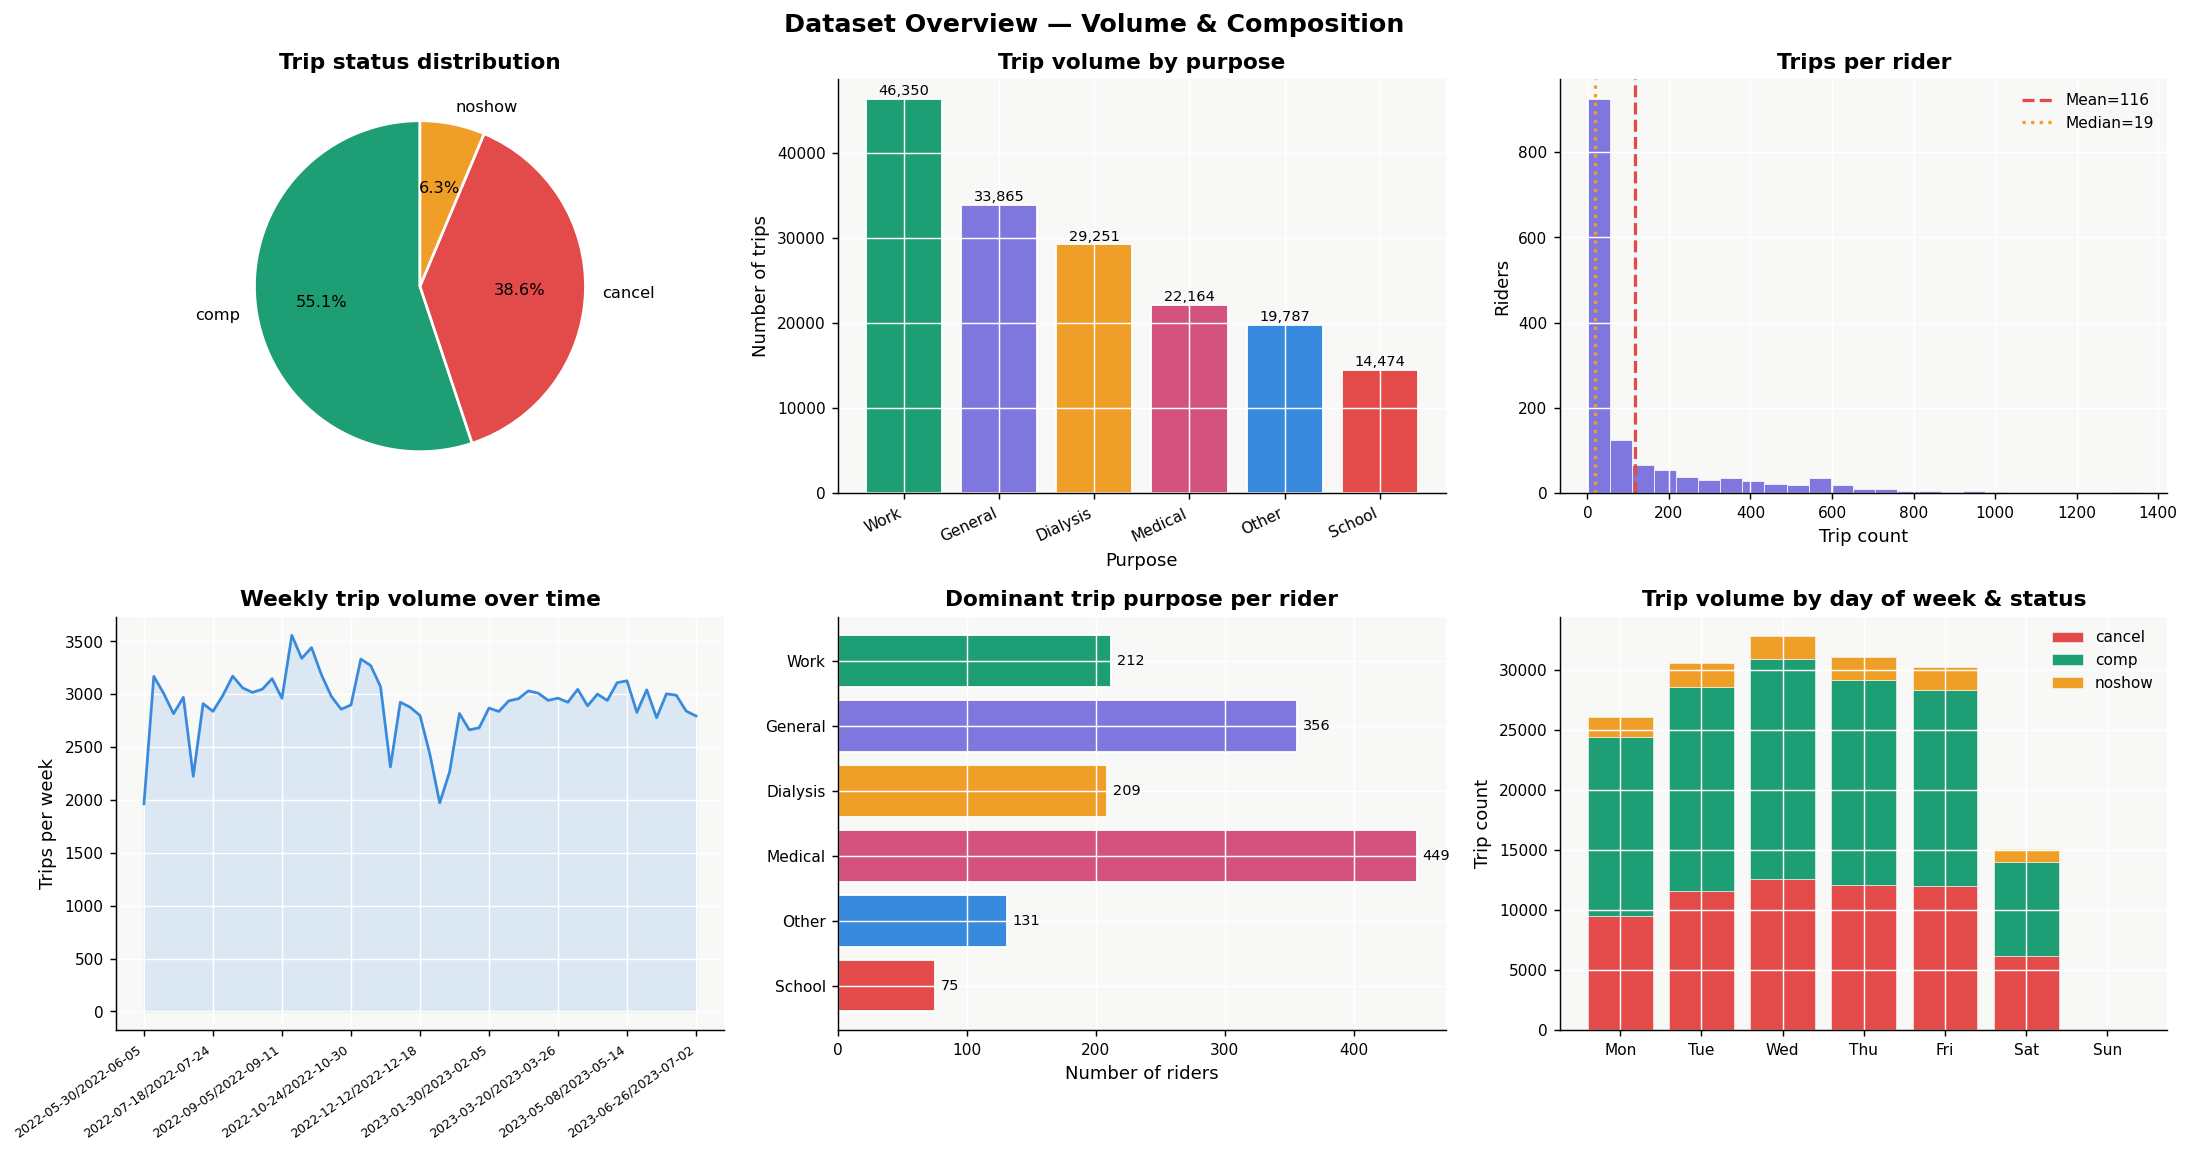

✓ Figure saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Dataset Overview — Volume & Composition',
             fontsize=14, fontweight='bold')
 
# ── 1. Trip status distribution ──────────────────────────────────
ax = axes[0, 0]
status_counts = df['Trip Status'].value_counts(dropna=True)
ax.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=[STATUS_COLORS.get(s, '#888780') for s in status_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9}
)
ax.set_title('Trip status distribution')
 
# ── 2. Trip volume by purpose ─────────────────────────────────────
ax = axes[0, 1]
# Use actual PURPOSE_ORDER (auto-detected), drop NaN
purp_counts = (
    df['Purpose']
    .value_counts(dropna=True)
    .reindex(PURPOSE_ORDER)          
    .dropna()                        
)
bars = ax.bar(
    purp_counts.index,
    purp_counts.values,
    color=[PALETTE.get(p, '#888780') for p in purp_counts.index],
    edgecolor='white'
)
for bar, val in zip(bars, purp_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + purp_counts.max() * 0.01,
            f'{int(val):,}', ha='center', fontsize=8)
ax.set_title('Trip volume by purpose')
ax.set_ylabel('Number of trips')
ax.set_xlabel('Purpose')
ax.set_xticklabels(purp_counts.index, rotation=25, ha='right')
 
# ── 3. Trips per rider ────────────────────────────────────────────
ax = axes[0, 2]
trips_per_rider = df.groupby('Customer Number')['Trip ID'].count()
ax.hist(trips_per_rider, bins=25, color='#7F77DD',
        edgecolor='white', linewidth=0.4)
ax.axvline(trips_per_rider.mean(), color='#E24B4A', linewidth=1.8,
           linestyle='--', label=f'Mean={trips_per_rider.mean():.0f}')
ax.axvline(trips_per_rider.median(), color='#EF9F27', linewidth=1.8,
           linestyle=':', label=f'Median={trips_per_rider.median():.0f}')
ax.set_title('Trips per rider')
ax.set_xlabel('Trip count')
ax.set_ylabel('Riders')
ax.legend(frameon=False)
 
# ── 4. Weekly trip volume over time ──────────────────────────────
ax = axes[1, 0]
# Use only rows where Trip Date is valid
weekly = (
    df.dropna(subset=['Trip Date'])
    .groupby(df.loc[df['Trip Date'].notna(), 'Trip Date']
             .dt.to_period('W').astype(str))
    .size()
)
if len(weekly) > 0:
    ax.plot(range(len(weekly)), weekly.values, color='#378ADD', linewidth=1.5)
    ax.fill_between(range(len(weekly)), weekly.values, alpha=0.15, color='#378ADD')
    step = max(1, len(weekly) // 8)
    ax.set_xticks(range(0, len(weekly), step))
    ax.set_xticklabels(list(weekly.index)[::step],
                        rotation=35, ha='right', fontsize=7)
ax.set_title('Weekly trip volume over time')
ax.set_ylabel('Trips per week')
 
# ── 5. Dominant purpose per rider ────────────────────────────────
ax = axes[1, 1]
dom_purpose = (
    df.groupby('Customer Number')['Purpose']
    .apply(lambda x: x.dropna().mode().iloc[0] if len(x.dropna()) > 0 else np.nan)
    .dropna()
)
dom_counts = (
    dom_purpose.value_counts()
    .reindex(PURPOSE_ORDER)
    .dropna()                       
)
if len(dom_counts) > 0:
    ax.barh(
        dom_counts.index[::-1],
        dom_counts.values[::-1],
        color=[PALETTE.get(p, '#888780') for p in dom_counts.index[::-1]],
        edgecolor='white'
    )
    for i, (p, v) in enumerate(zip(dom_counts.index[::-1],
                                    dom_counts.values[::-1])):
        ax.text(v + dom_counts.max() * 0.01, i,
                f'{int(v):,}', va='center', fontsize=8)
ax.set_title('Dominant trip purpose per rider')
ax.set_xlabel('Number of riders')
 
# ── 6. Trips by day of week + status ─────────────────────────────
ax = axes[1, 2]
dow_order = ['Monday','Tuesday','Wednesday','Thursday',
              'Friday','Saturday','Sunday']
 
# Only use rows where dow is valid
df_dow = df.dropna(subset=['dow'])
dow_status = (
    df_dow.groupby(['dow', 'Trip Status'])
    .size()
    .unstack(fill_value=0)
)
# Reindex to full week — fill missing days with 0
dow_status = dow_status.reindex(dow_order, fill_value=0)
 
bottom = np.zeros(len(dow_order))
for status in dow_status.columns:
    col = STATUS_COLORS.get(status, '#888780')
    vals = dow_status[status].values.astype(float)
    ax.bar(range(7), vals, bottom=bottom, color=col,
           label=str(status), edgecolor='white', linewidth=0.3)
    bottom += vals
 
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_title('Trip volume by day of week & status')
ax.set_ylabel('Trip count')
# Only add legend if there are labelled artists
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(frameon=False)
 
plt.tight_layout()
plt.savefig('eda_fig1_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figure saved')

## 4. Pickup Window Analysis
> `pickup_window = Latest Pick-up Time − Earliest Pick-up`

This is the **most direct signal of scheduling tolerance**: how many minutes of slack did the agency allow around the rider's pickup.

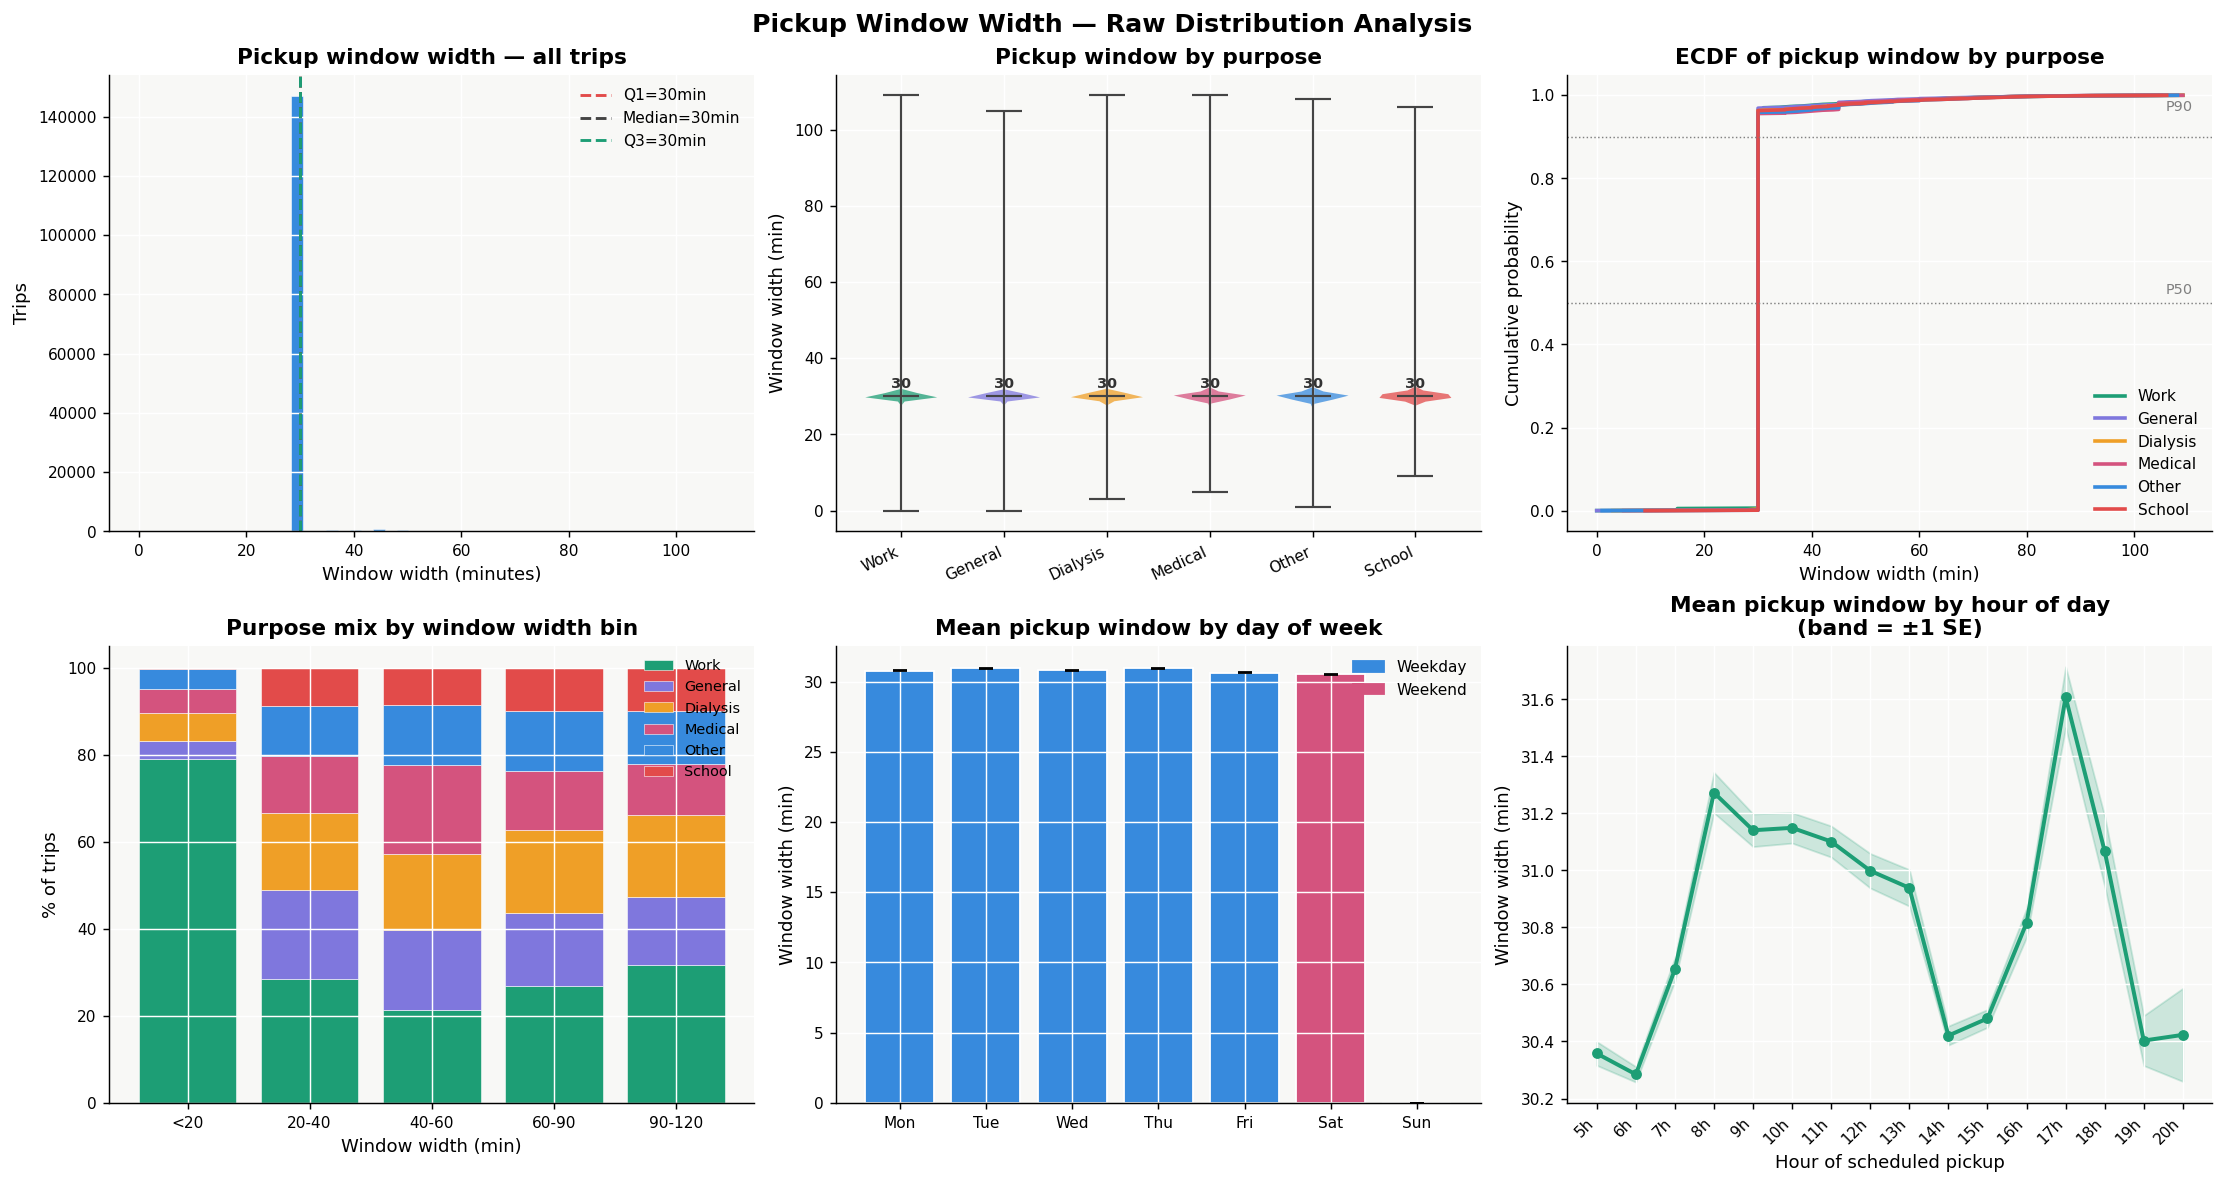


── Pickup Window Summary by Purpose ──────────────────────


,count,mean,std,min,25%,50%,75%,max
Purpose,,,,,,,,
Work,43432.0,30.7,5.2,0.0,30.0,30.0,30.0,109.0
General,31005.0,30.7,4.9,0.0,30.0,30.0,30.0,105.0
Dialysis,26979.0,30.9,5.5,3.0,30.0,30.0,30.0,109.0
Medical,20469.0,31.0,5.4,5.0,30.0,30.0,30.0,109.0
Other,17643.0,31.0,5.7,1.0,30.0,30.0,30.0,108.0
School,13330.0,30.9,5.6,9.0,30.0,30.0,30.0,106.0


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(17, 9),
                          constrained_layout=True)  
fig.suptitle('Pickup Window Width — Raw Distribution Analysis',
             fontsize=14, fontweight='bold')

avail_purposes = [p for p in PURPOSE_ORDER if p in dc['Purpose'].unique()]
dow_order = ['Monday','Tuesday','Wednesday','Thursday',
              'Friday','Saturday','Sunday']

# ── 1. Overall histogram ─────────────────────────────────────────
ax = axes[0, 0]
pw_clean = dc['pickup_window'].dropna()
ax.hist(pw_clean, bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
for q, c, l in zip([0.25, 0.50, 0.75],
                    ['#E24B4A', '#444', '#1D9E75'],
                    ['Q1', 'Median', 'Q3']):
    v = pw_clean.quantile(q)
    ax.axvline(v, color=c, linewidth=1.6, linestyle='--',
               label=f'{l}={v:.0f}min')
ax.set_title('Pickup window width — all trips')
ax.set_xlabel('Window width (minutes)')
ax.set_ylabel('Trips')
ax.legend(frameon=False)

# ── 2. Violin by purpose ─────────────────────────────────────────
ax = axes[0, 1]
violin_data = [dc[dc['Purpose']==p]['pickup_window'].dropna().values
                for p in avail_purposes]

violin_data_filtered = [(d, p) for d, p in zip(violin_data, avail_purposes)
                         if len(d) > 1 and d.std() > 0]

if violin_data_filtered:
    parts = ax.violinplot(
        [d for d, _ in violin_data_filtered],
        positions=range(len(violin_data_filtered)),
        showmedians=True, showextrema=True, widths=0.7
    )
    for body, (_, p) in zip(parts['bodies'], violin_data_filtered):
        body.set_facecolor(PALETTE.get(p, '#888'))
        body.set_alpha(0.75)
    for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
        parts[part].set_color('#444')
        parts[part].set_linewidth(1.2)
    ax.set_xticks(range(len(violin_data_filtered)))
    ax.set_xticklabels([p for _, p in violin_data_filtered],
                        rotation=25, ha='right')
    # Annotate medians
    for i, (d, p) in enumerate(violin_data_filtered):
        med = np.median(d)
        ax.text(i, med + ax.get_ylim()[1] * 0.02,
                f'{med:.0f}', ha='center', fontsize=8,
                color='#333', fontweight='bold')
ax.set_title('Pickup window by purpose')
ax.set_ylabel('Window width (min)')

# ── 3. ECDF by purpose  ──────────────────────────────────────────

ax = axes[0, 2]
MAX_ECDF_PTS = 1000
for p in avail_purposes:
    raw = dc[dc['Purpose']==p]['pickup_window'].dropna().values
    if len(raw) == 0:
        continue
    vals = np.sort(raw)
    # Downsample evenly if too many points
    if len(vals) > MAX_ECDF_PTS:
        idx  = np.linspace(0, len(vals)-1, MAX_ECDF_PTS).astype(int)
        vals = vals[idx]
    yvals = np.linspace(0, 1, len(vals))
    ax.plot(vals, yvals, color=PALETTE.get(p, '#888'),
            linewidth=2, label=p)

ax.axhline(0.5, color='gray', linewidth=0.8, linestyle=':')
ax.axhline(0.9, color='gray', linewidth=0.8, linestyle=':')

ax.text(0.97, 0.52, 'P50', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray')
ax.text(0.97, 0.92, 'P90', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray')
ax.set_title('ECDF of pickup window by purpose')
ax.set_xlabel('Window width (min)')
ax.set_ylabel('Cumulative probability')
ax.legend(frameon=False)

# ── 4. Window width bins — stacked bar ───────────────────────────
ax = axes[1, 0]
dc['window_bin'] = pd.cut(
    dc['pickup_window'],
    bins=[0, 20, 40, 60, 90, 120, 999],
    labels=['<20','20-40','40-60','60-90','90-120','>120']
)
wbin_purp = (dc.groupby(['window_bin','Purpose'], observed=True)
               .size()
               .unstack(fill_value=0))
wbin_purp_pct = wbin_purp.div(wbin_purp.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(wbin_purp_pct))
for p in avail_purposes:
    if p in wbin_purp_pct.columns:
        vals = wbin_purp_pct[p].fillna(0).values
        ax.bar(wbin_purp_pct.index, vals, bottom=bottom,
               color=PALETTE.get(p, '#888'), label=p,
               edgecolor='white', linewidth=0.3)
        bottom += vals
ax.set_title('Purpose mix by window width bin')
ax.set_xlabel('Window width (min)')
ax.set_ylabel('% of trips')

ax.legend(frameon=False, loc='upper right', fontsize=8)

# ── 5. Mean window by day of week ────────────────────────────────
ax = axes[1, 1]
dc_dow = dc.dropna(subset=['dow'])
dow_window = (dc_dow.groupby('dow')['pickup_window']
                     .agg(['mean','sem'])
                     .reindex(dow_order))

dow_mean = dow_window['mean'].fillna(0).values
dow_sem  = dow_window['sem'].fillna(0).values
colors_dow = ['#378ADD']*5 + ['#D4537E']*2
ax.bar(range(7), dow_mean, color=colors_dow, edgecolor='white',
       yerr=dow_sem, capsize=4,
       error_kw={'linewidth':1, 'color':'#555'})
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_title('Mean pickup window by day of week')
ax.set_ylabel('Window width (min)')
ax.legend(handles=[
    mpatches.Patch(color='#378ADD', label='Weekday'),
    mpatches.Patch(color='#D4537E', label='Weekend')
], frameon=False)

# ── 6. Mean window by hour of day ────────────────────────────────
ax = axes[1, 2]
dc_hr = dc.dropna(subset=['pu_hour'])
hourly_win = (dc_hr.groupby('pu_hour')['pickup_window']
                    .agg(['mean','sem']))
hourly_win = hourly_win[
    (hourly_win.index >= 5) & (hourly_win.index <= 20)
]

x_hours = hourly_win.index.astype(float).to_numpy()
y_mean  = hourly_win['mean'].to_numpy(dtype=float)
y_sem   = hourly_win['sem'].fillna(0).to_numpy(dtype=float)

ax.fill_between(x_hours, y_mean - y_sem, y_mean + y_sem,
                alpha=0.2, color='#1D9E75')
ax.plot(x_hours, y_mean, color='#1D9E75',
        linewidth=2.2, marker='o', markersize=5)
ax.set_xticks(x_hours)
ax.set_xticklabels([f'{int(h)}h' for h in x_hours],
                    rotation=45, ha='right')
ax.set_title('Mean pickup window by hour of day\n(band = ±1 SE)')
ax.set_xlabel('Hour of scheduled pickup')
ax.set_ylabel('Window width (min)')


plt.savefig('eda_fig2_pickup_window.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n── Pickup Window Summary by Purpose ──────────────────────')
display(dc.groupby('Purpose')['pickup_window']
          .describe().round(1)
          .reindex(avail_purposes))

## 5. Dropoff Slack Analysis
> `dropoff_slack = Latest Drop-off Time − Requested Drop-off Time`

This measures tolerance at the destination — how much lateness is acceptable. Dialysis and school trips are expected to have near-zero slack.

ValueError: Inputs must not be empty.

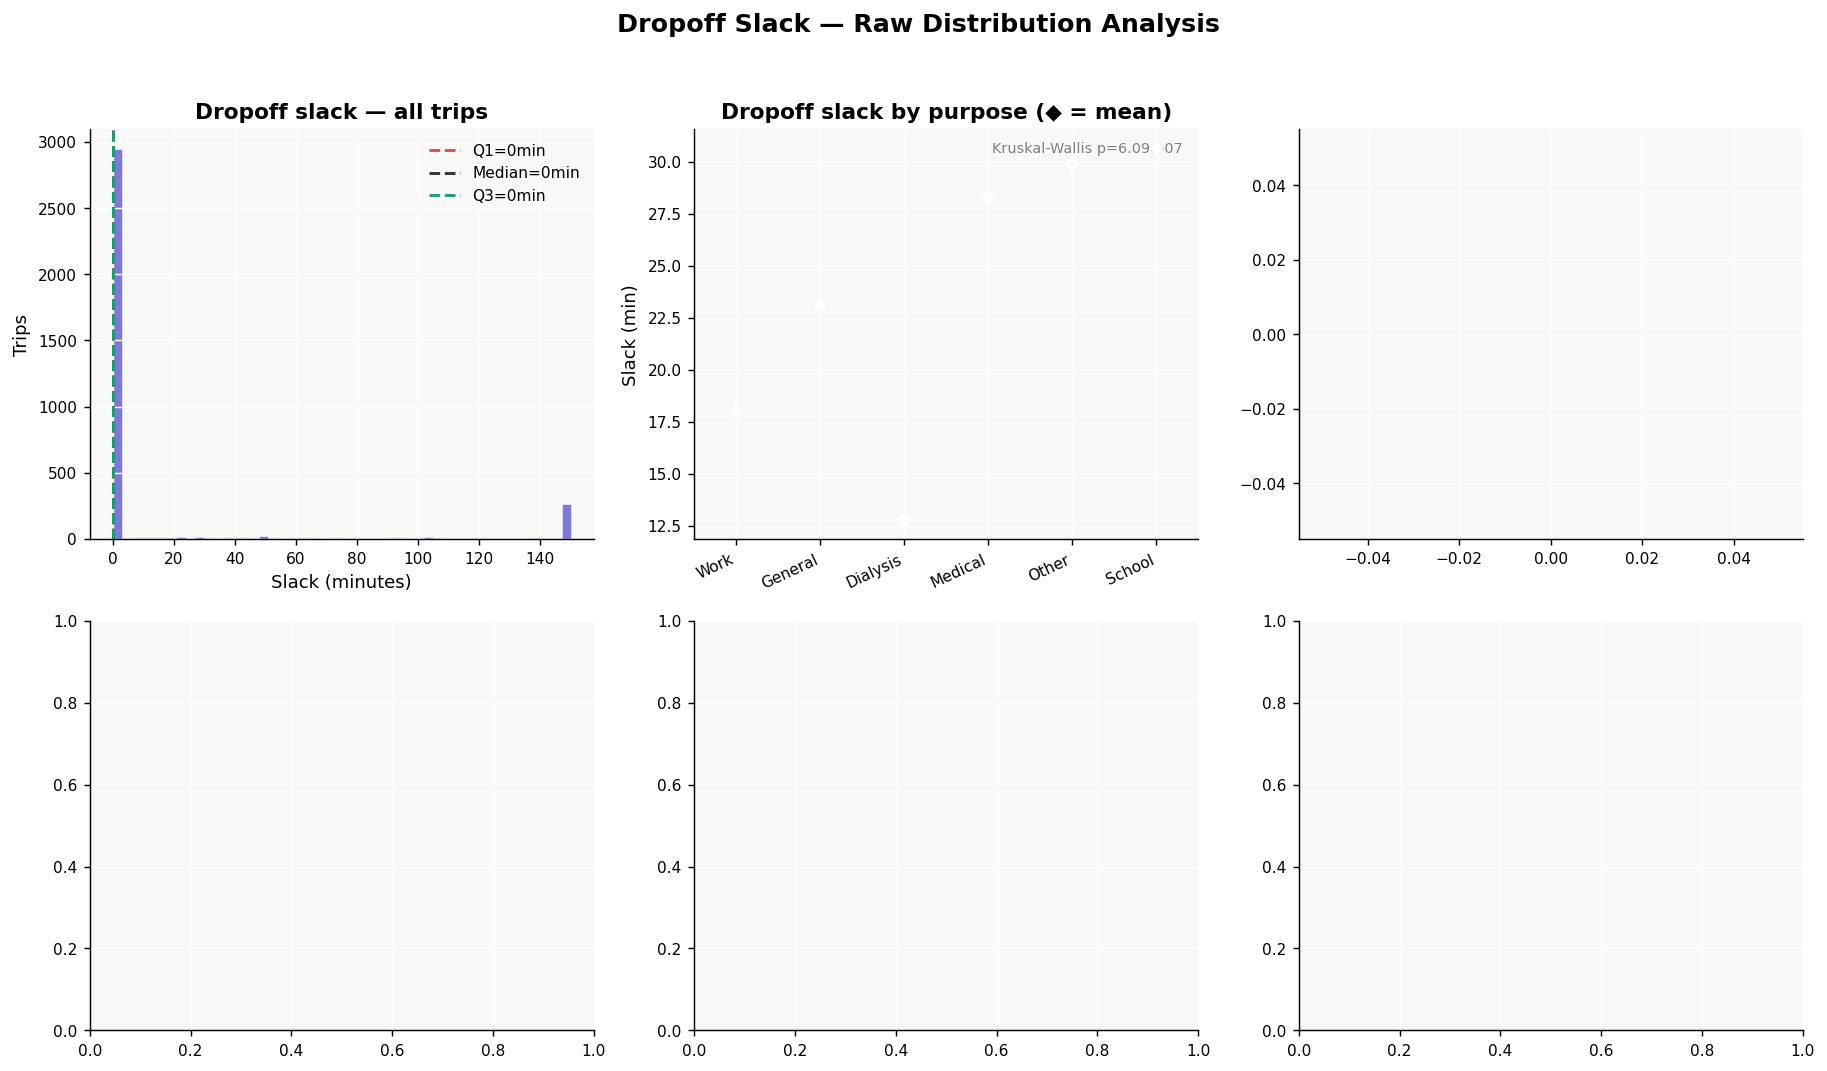

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Dropoff Slack — Raw Distribution Analysis', fontsize=14, fontweight='bold')

# 1. Overall histogram
ax = axes[0,0]
ax.hist(dc['dropoff_slack'].clip(upper=150), bins=50,
        color='#7F77DD', edgecolor='white', linewidth=0.3)
for q, c, l in zip([0.25,0.50,0.75], ['#E24B4A','#333','#1D9E75'],['Q1','Median','Q3']):
    v = dc['dropoff_slack'].quantile(q)
    ax.axvline(v, color=c, linewidth=1.6, linestyle='--', label=f'{l}={v:.0f}min')
ax.set_title('Dropoff slack — all trips')
ax.set_xlabel('Slack (minutes)'); ax.set_ylabel('Trips'); ax.legend(frameon=False)

# 2. Box plot by purpose
ax = axes[0,1]
bp = ax.boxplot(
    [dc[dc['Purpose']==p]['dropoff_slack'].clip(upper=150).values for p in PURPOSE_ORDER],
    labels=PURPOSE_ORDER, patch_artist=True, notch=True, showfliers=False,
    medianprops={'color':'white','linewidth':2})
for patch, p in zip(bp['boxes'], PURPOSE_ORDER):
    patch.set_facecolor(PALETTE[p]); patch.set_alpha(0.85)
ax.set_title('Dropoff slack by purpose (◆ = mean)')
ax.set_ylabel('Slack (min)'); ax.set_xticklabels(PURPOSE_ORDER, rotation=25, ha='right')
for i, p in enumerate(PURPOSE_ORDER):
    mean_v = dc[dc['Purpose']==p]['dropoff_slack'].mean()
    ax.plot(i+1, mean_v, 'D', color='white', markersize=5, zorder=5)
kstat, kp = kruskal(*[dc[dc['Purpose']==p]['dropoff_slack'].dropna() for p in PURPOSE_ORDER])
ax.text(0.97, 0.97, f'Kruskal-Wallis p={kp:.2e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='gray')

# 3. Pickup window vs dropoff slack scatter
ax = axes[0,2]
for p in PURPOSE_ORDER:
    sub = dc[dc['Purpose']==p]
    ax.scatter(sub['pickup_window'], sub['dropoff_slack'],
               color=PALETTE[p], alpha=0.25, s=12, label=p, edgecolors='none')
# Add regression line
valid = dc[['pickup_window','dropoff_slack']].dropna()
m, b, r, p_r, _ = stats.linregress(valid['pickup_window'], valid['dropoff_slack'])
xs = np.linspace(valid['pickup_window'].min(), valid['pickup_window'].max(), 100)
ax.plot(xs, m*xs+b, color='#333', linewidth=1.5, linestyle='--',
        label=f'OLS r={r:.2f}')
ax.set_title('Pickup window vs dropoff slack')
ax.set_xlabel('Pickup window (min)'); ax.set_ylabel('Dropoff slack (min)')
ax.legend(frameon=False, markerscale=2)

# 4. Joint distribution — 2D KDE per purpose
ax = axes[1,0]
for p in PURPOSE_ORDER:
    sub = dc[dc['Purpose']==p][['pickup_window','dropoff_slack']].dropna()
    if len(sub) < 20: continue
    try:
        kde = stats.gaussian_kde(sub.T)
        xg  = np.linspace(0, 150, 60)
        yg  = np.linspace(0, 100, 60)
        Xg, Yg = np.meshgrid(xg, yg)
        Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
        ax.contour(Xg, Yg, Z, levels=4, colors=[PALETTE[p]], alpha=0.7, linewidths=1.2)
    except:
        pass
patches = [mpatches.Patch(color=PALETTE[p], label=p) for p in PURPOSE_ORDER]
ax.legend(handles=patches, frameon=False)
ax.set_title('2D density contours: window vs slack\n(per purpose)')
ax.set_xlabel('Pickup window (min)'); ax.set_ylabel('Dropoff slack (min)')

# 5. Dropoff slack by time bin
ax = axes[1,1]
tb_slack = dc.groupby('time_bin', observed=True)['dropoff_slack'].agg(['mean','sem'])
ax.barh(tb_slack.index, tb_slack['mean'],
        xerr=tb_slack['sem'], color='#7F77DD', edgecolor='white',
        error_kw={'linewidth':1,'color':'#555'})
ax.set_title('Mean dropoff slack by pickup time bin')
ax.set_xlabel('Dropoff slack (min)')

# 6. Percent of trips with zero dropoff slack
ax = axes[1,2]
zero_slack = dc.groupby('Purpose').apply(lambda x: (x['dropoff_slack']==0).mean()*100).reindex(PURPOSE_ORDER)
bars = ax.bar(PURPOSE_ORDER, zero_slack.values,
               color=[PALETTE[p] for p in PURPOSE_ORDER], edgecolor='white')
for bar, val in zip(bars, zero_slack.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=8.5, fontweight='bold')
ax.set_title('Trips with zero dropoff slack (%)\n→ rigid destination timing')
ax.set_ylabel('%  of trips'); ax.set_xticklabels(PURPOSE_ORDER, rotation=25, ha='right')

plt.tight_layout()
plt.savefig('eda_fig3_dropoff_slack.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n── Dropoff Slack Summary by Purpose ──────────────────────')
print(dc.groupby('Purpose')['dropoff_slack'].describe().round(1).reindex(PURPOSE_ORDER).to_string())

## 6. Scheduling Position Within Window
> `window_used_frac = (Scheduled − Earliest) / (Latest − Earliest)`

Where **0** = scheduled at the very start of the window (tight), **1** = scheduled at the very end. This reveals whether flexible riders are being used to absorb scheduling slack.

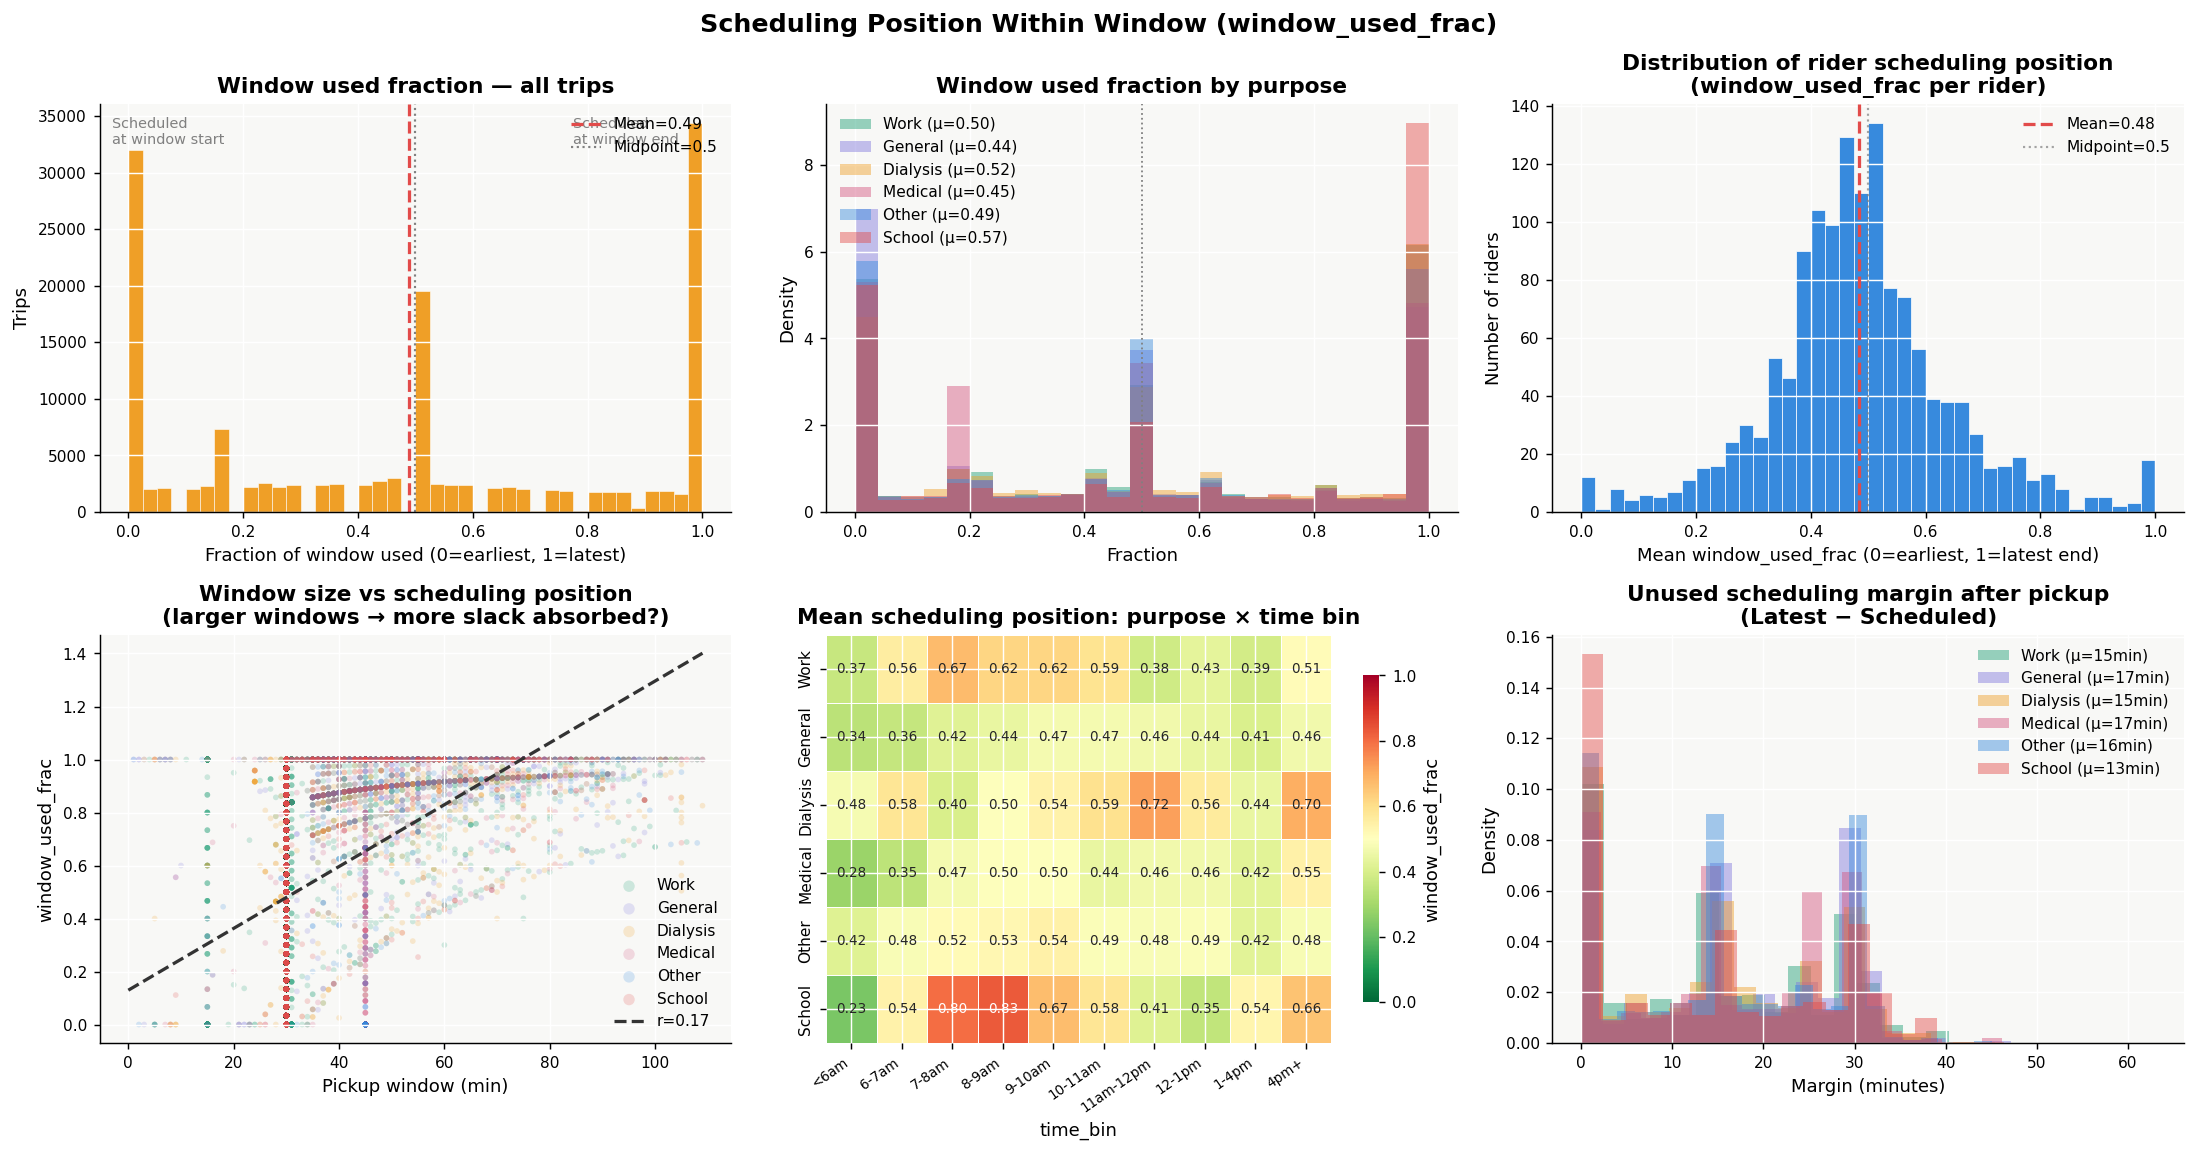

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Scheduling Position Within Window (window_used_frac)', fontsize=14, fontweight='bold')

# 1. Overall histogram
ax = axes[0,0]
ax.hist(dc['window_used_frac'], bins=40, color='#EF9F27', edgecolor='white', linewidth=0.3)
ax.axvline(dc['window_used_frac'].mean(), color='#E24B4A', linewidth=1.8,
           linestyle='--', label=f"Mean={dc['window_used_frac'].mean():.2f}")
ax.axvline(0.5, color='gray', linewidth=1.2, linestyle=':', label='Midpoint=0.5')
ax.set_title('Window used fraction — all trips')
ax.set_xlabel('Fraction of window used (0=earliest, 1=latest)')
ax.set_ylabel('Trips'); ax.legend(frameon=False)
ax.text(0.02, 0.9, 'Scheduled\nat window start', transform=ax.transAxes,
        fontsize=8, color='gray')
ax.text(0.75, 0.9, 'Scheduled\nat window end', transform=ax.transAxes,
        fontsize=8, color='gray')

# 2. Histogram overlay by purpose
ax = axes[0,1]
for p in PURPOSE_ORDER:
    vals = dc[dc['Purpose']==p]['window_used_frac'].dropna()
    ax.hist(vals, bins=25, alpha=0.45, color=PALETTE[p],
            label=f'{p} (μ={vals.mean():.2f})', density=True, edgecolor='none')
ax.axvline(0.5, color='gray', linewidth=1, linestyle=':')
ax.set_title('Window used fraction by purpose')
ax.set_xlabel('Fraction'); ax.set_ylabel('Density'); ax.legend(frameon=False)

# 3. Mean window_used_frac per rider (ranked)
ax = axes[0,2]
rider_frac = dc.groupby('Customer Number')['window_used_frac'].mean().dropna()
colors_rank = plt.cm.RdYlGn_r(np.linspace(0, 1, len(rider_frac)))
ax.hist(rider_frac.values, bins=40, color='#378ADD',
        edgecolor='white', linewidth=0.4)
ax.axvline(rider_frac.mean(),   color='#E24B4A', lw=1.8, ls='--',
           label=f'Mean={rider_frac.mean():.2f}')
ax.axvline(0.5, color='gray', lw=1.2, ls=':', alpha=0.7,
           label='Midpoint=0.5')
ax.set_title('Distribution of rider scheduling position\n(window_used_frac per rider)')
ax.set_xlabel('Mean window_used_frac (0=earliest, 1=latest end)')
ax.set_ylabel('Number of riders')
ax.legend(frameon=False)

# 4. window_used_frac vs pickup_window size (do bigger windows get used more?)
ax = axes[1,0]
for p in PURPOSE_ORDER:
    sub = dc[dc['Purpose']==p]
    ax.scatter(sub['pickup_window'], sub['window_used_frac'],
               color=PALETTE[p], alpha=0.2, s=10, label=p, edgecolors='none')
valid = dc[['pickup_window','window_used_frac']].dropna()
m, b, r, _, _ = stats.linregress(valid['pickup_window'], valid['window_used_frac'])
xs = np.linspace(0, valid['pickup_window'].max(), 100)
ax.plot(xs, m*xs+b, color='#333', linewidth=1.8, linestyle='--',
        label=f'r={r:.2f}')
ax.set_title('Window size vs scheduling position\n(larger windows → more slack absorbed?)')
ax.set_xlabel('Pickup window (min)'); ax.set_ylabel('window_used_frac')
ax.legend(frameon=False, markerscale=2)

# 5. Mean window_used_frac by time bin × purpose (heatmap)
ax = axes[1,1]
pivot_frac = dc.groupby(['Purpose','time_bin'], observed=True)['window_used_frac'].mean().unstack()
pivot_frac = pivot_frac.reindex(PURPOSE_ORDER)
sns.heatmap(pivot_frac, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.4, vmin=0, vmax=1,
            cbar_kws={'shrink':0.8, 'label':'window_used_frac'},
            annot_kws={'size':7.5})
ax.set_title('Mean scheduling position: purpose × time bin')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=7.5)
ax.set_ylabel('')

# 6. Unused margin (sched_margin) distribution
ax = axes[1,2]
for p in PURPOSE_ORDER:
    vals = dc[dc['Purpose']==p]['sched_margin'].clip(upper=120).dropna()
    ax.hist(vals, bins=25, alpha=0.45, color=PALETTE[p],
            label=f'{p} (μ={vals.mean():.0f}min)', density=True, edgecolor='none')
ax.set_title('Unused scheduling margin after pickup\n(Latest − Scheduled)')
ax.set_xlabel('Margin (minutes)'); ax.set_ylabel('Density')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('eda_fig4_sched_position.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Rider-Level Temporal Flexibility Portraits

ValueError: Inputs must not be empty.

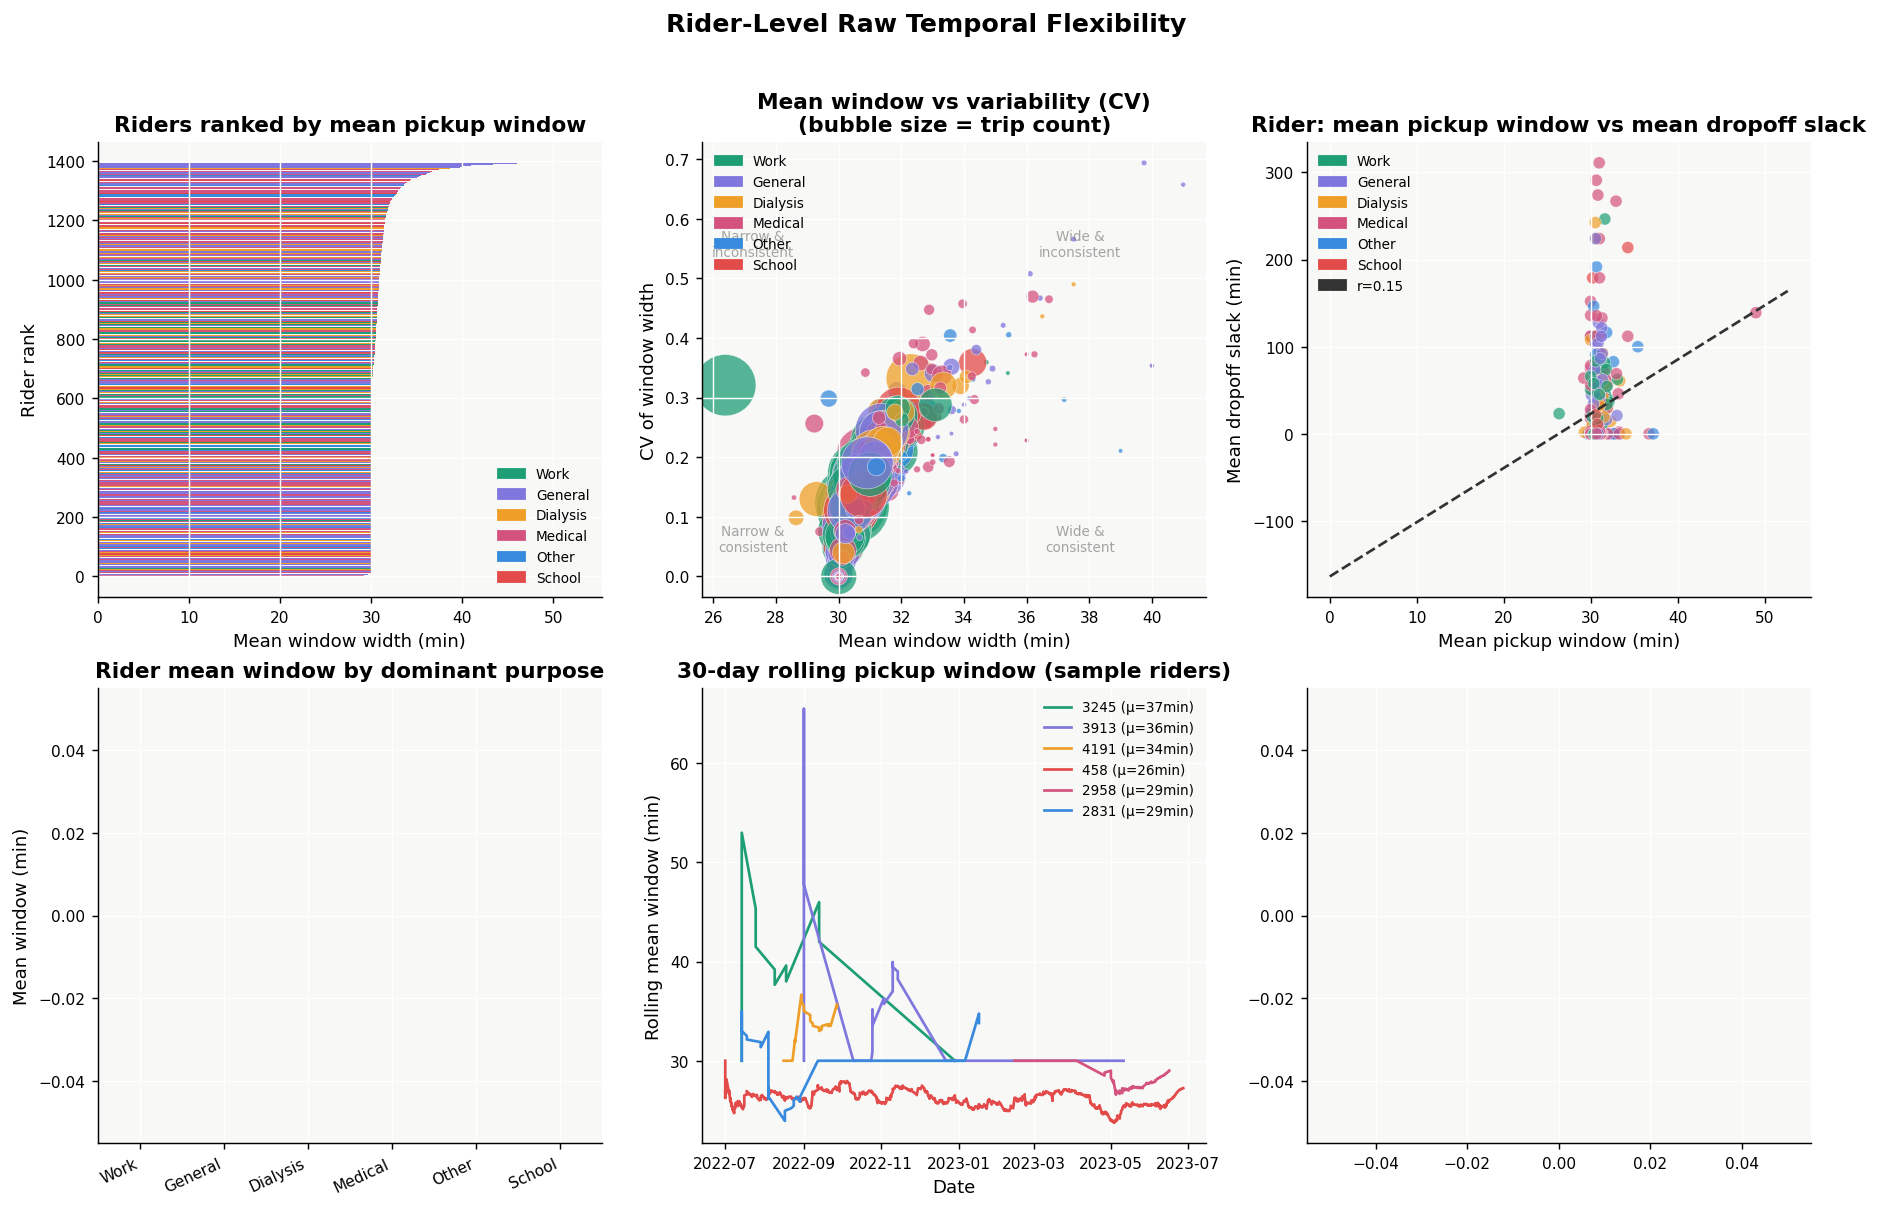

In [24]:
rider_raw = dc.groupby('Customer Number').agg(
    n_trips           = ('Trip ID',          'count'),
    mean_window       = ('pickup_window',     'mean'),
    std_window        = ('pickup_window',     'std'),
    median_window     = ('pickup_window',     'median'),
    mean_do_slack     = ('dropoff_slack',     'mean'),
    median_do_slack   = ('dropoff_slack',     'median'),
    mean_sched_frac   = ('window_used_frac',  'mean'),
    std_sched_frac    = ('window_used_frac',  'std'),
    mean_sched_margin = ('sched_margin',      'mean'),
    dom_purpose       = ('Purpose',           lambda x: x.mode()[0]),
    n_purposes        = ('Purpose',           'nunique'),
    cancel_rate       = ('Trip ID',           lambda x: (df[df['Customer Number']==x.name]['Trip Status']=='Cancelled').mean()),
).reset_index()
rider_raw['cv_window'] = rider_raw['std_window'] / rider_raw['mean_window'].replace(0, np.nan)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Rider-Level Raw Temporal Flexibility', fontsize=14, fontweight='bold')

# 1. Mean window per rider, coloured by dominant purpose
ax = axes[0,0]
rider_sorted = rider_raw.sort_values('mean_window')
colors_r = [PALETTE[p] for p in rider_sorted['dom_purpose']]
ax.barh(range(len(rider_sorted)), rider_sorted['mean_window'],
        color=colors_r, height=0.85, edgecolor='none')
ax.set_title('Riders ranked by mean pickup window')
ax.set_xlabel('Mean window width (min)'); ax.set_ylabel('Rider rank')
patches = [mpatches.Patch(color=PALETTE[p], label=p) for p in PURPOSE_ORDER]
ax.legend(handles=patches, frameon=False, fontsize=7.5)

# 2. Mean window vs consistency (CV)
ax = axes[0,1]
rs = rider_raw[rider_raw['n_trips'] >= 5]
sc = ax.scatter(rs['mean_window'], rs['cv_window'],
                c=[list(PALETTE.values())[PURPOSE_ORDER.index(p)] for p in rs['dom_purpose']],
                alpha=0.75, s=rs['n_trips']*1.2, edgecolors='white', linewidth=0.3)
ax.set_title('Mean window vs variability (CV)\n(bubble size = trip count)')
ax.set_xlabel('Mean window width (min)'); ax.set_ylabel('CV of window width')
for qx, qy, lbl in [(0.75,0.75,'Wide &\ninconsistent'),(0.1,0.75,'Narrow &\ninconsistent'),
                     (0.75,0.1,'Wide &\nconsistent'),(0.1,0.1,'Narrow &\nconsistent')]:
    ax.text(qx, qy, lbl, transform=ax.transAxes, fontsize=7.5, color='gray',
            ha='center', alpha=0.7)
patches = [mpatches.Patch(color=PALETTE[p], label=p) for p in PURPOSE_ORDER]
ax.legend(handles=patches, frameon=False, fontsize=7.5)

# 3. Mean window vs mean dropoff slack
ax = axes[0,2]
sc2 = ax.scatter(rider_raw['mean_window'], rider_raw['mean_do_slack'],
                  c=[PALETTE[p] for p in rider_raw['dom_purpose']],
                  alpha=0.7, s=45, edgecolors='white', linewidth=0.3)
m, b, r, _, _ = stats.linregress(
    rider_raw[['mean_window','mean_do_slack']].dropna()['mean_window'],
    rider_raw[['mean_window','mean_do_slack']].dropna()['mean_do_slack'])
xs = np.linspace(0, rider_raw['mean_window'].max(), 100)
ax.plot(xs, m*xs+b, '--', color='#333', linewidth=1.5, label=f'r={r:.2f}')
ax.set_title('Rider: mean pickup window vs mean dropoff slack')
ax.set_xlabel('Mean pickup window (min)'); ax.set_ylabel('Mean dropoff slack (min)')
patches = [mpatches.Patch(color=PALETTE[p], label=p) for p in PURPOSE_ORDER]
ax.legend(handles=patches+[mpatches.Patch(color='#333',label=f'r={r:.2f}')], frameon=False, fontsize=7.5)

# 4. Per-purpose distribution of mean rider window
ax = axes[1,0]
bp2 = ax.boxplot([rider_raw[rider_raw['dom_purpose']==p]['mean_window'].values for p in PURPOSE_ORDER],
                  labels=PURPOSE_ORDER, patch_artist=True, notch=True, showfliers=False,
                  medianprops={'color':'white','linewidth':2})
for patch, p in zip(bp2['boxes'], PURPOSE_ORDER):
    patch.set_facecolor(PALETTE[p]); patch.set_alpha(0.85)
ax.set_title('Rider mean window by dominant purpose')
ax.set_ylabel('Mean window (min)'); ax.set_xticklabels(PURPOSE_ORDER, rotation=25, ha='right')

# 5. Trip regularity: window stability over time (sample riders)
ax = axes[1,1]
sample_r = (rider_raw[rider_raw['n_trips']>=15]
             .sort_values('mean_window', ascending=False).head(3)['Customer Number'].tolist() +
             rider_raw[rider_raw['n_trips']>=15]
             .sort_values('mean_window').head(3)['Customer Number'].tolist())
p6 = ['#1D9E75','#7F77DD','#EF9F27','#E24B4A','#D4537E','#378ADD']
for rid, col in zip(sample_r, p6):
    sub = dc[dc['Customer Number']==rid].sort_values('Trip Date')
    if len(sub) < 4: continue
    roll = sub.set_index('Trip Date')['pickup_window'].rolling('30D').mean()
    mn   = rider_raw[rider_raw['Customer Number']==rid]['mean_window'].values[0]
    ax.plot(roll.index, roll.values, color=col, linewidth=1.5,
            label=f'{rid} (μ={mn:.0f}min)')
ax.set_title('30-day rolling pickup window (sample riders)')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling mean window (min)')
ax.legend(frameon=False, fontsize=7.5)

# 6. Cancel rate vs mean pickup window
ax = axes[1,2]
sc3 = ax.scatter(rider_raw['mean_window'], rider_raw['cancel_rate']*100,
                  c=[PALETTE[p] for p in rider_raw['dom_purpose']],
                  alpha=0.7, s=45, edgecolors='white', linewidth=0.3)
m2, b2, r2, _, _ = stats.linregress(
    rider_raw[['mean_window','cancel_rate']].dropna()['mean_window'],
    rider_raw[['mean_window','cancel_rate']].dropna()['cancel_rate']*100)
xs2 = np.linspace(0, rider_raw['mean_window'].max(), 100)
ax.plot(xs2, m2*xs2+b2, '--', color='#333', linewidth=1.5)
ax.set_title('Mean pickup window vs cancellation rate\n(wider window → more cancel?)')
ax.set_xlabel('Mean pickup window (min)'); ax.set_ylabel('Cancellation rate (%)')
ax.text(0.97, 0.03, f'r={r2:.2f}', transform=ax.transAxes,
        ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('eda_fig5_rider_portraits.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Cancellation & No-Show Temporal Patterns

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


KeyError: '_cancel_lead_min'

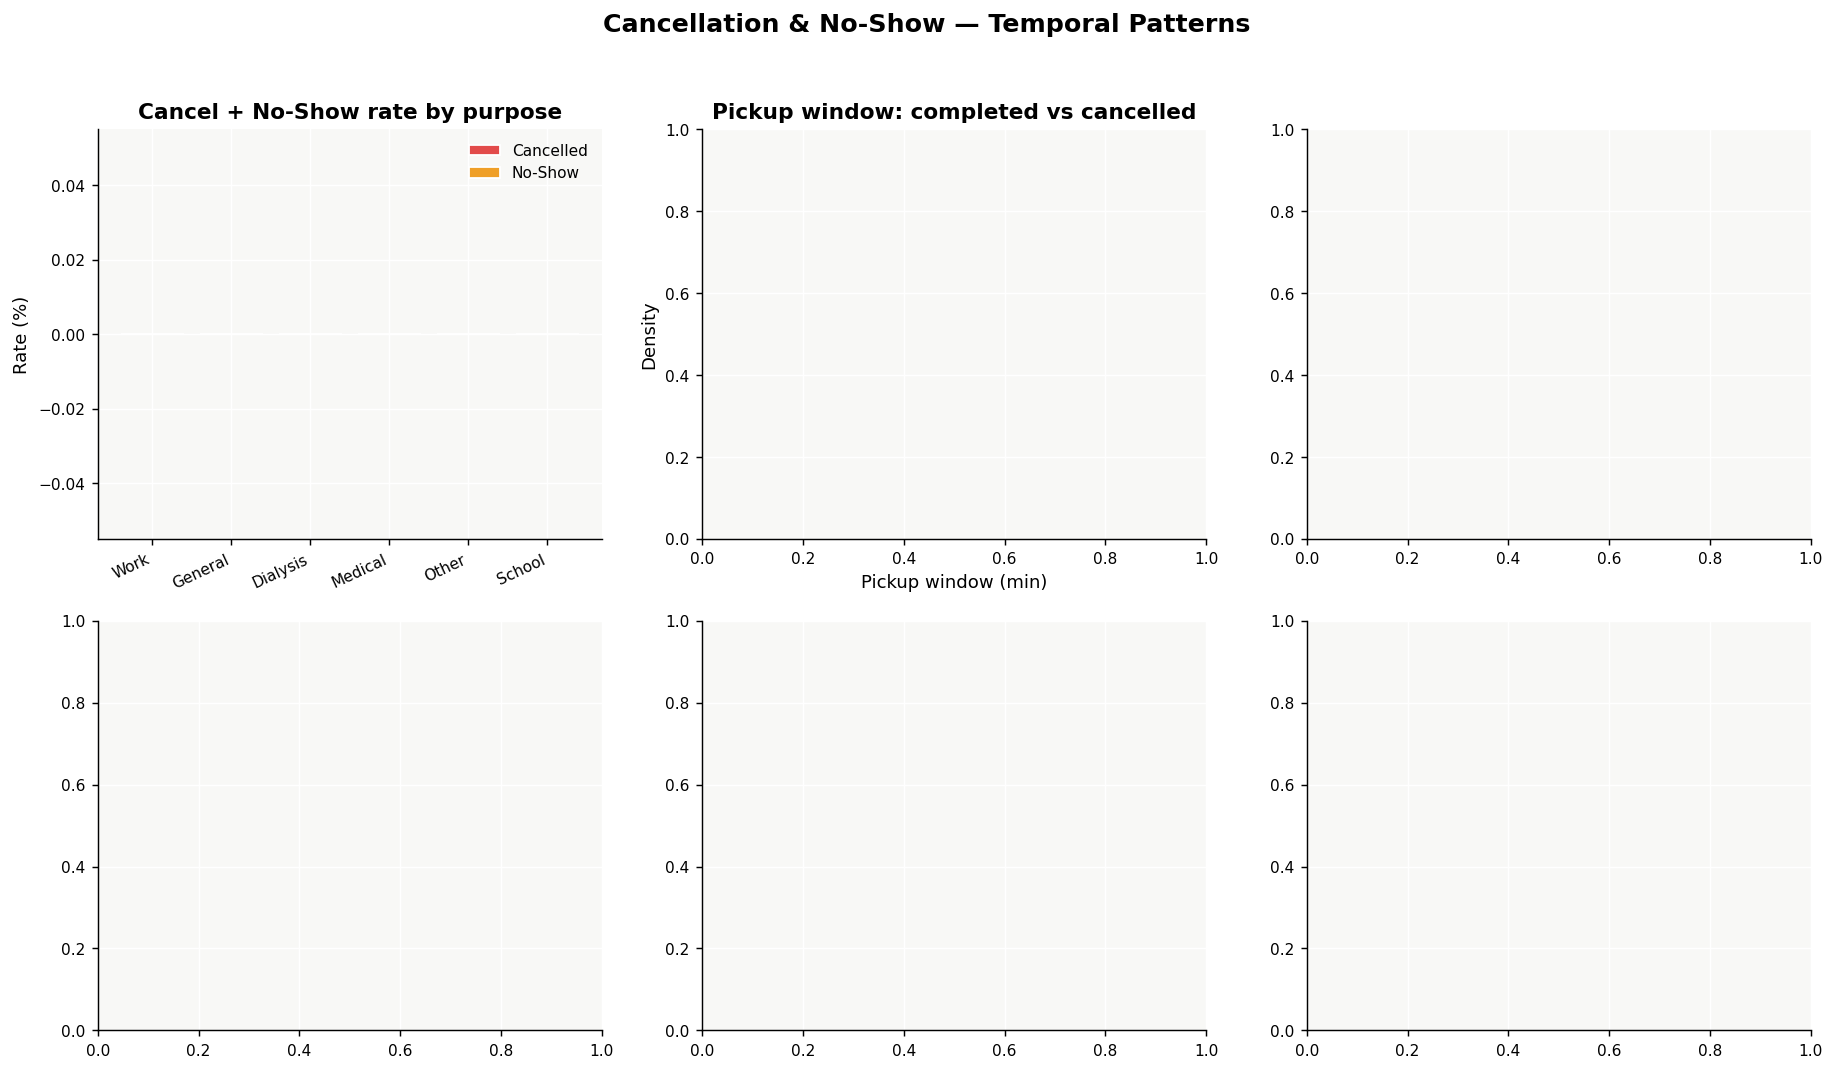

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Cancellation & No-Show — Temporal Patterns', fontsize=14, fontweight='bold')

# 1. Cancel/no-show rate by purpose
ax = axes[0,0]
cancel_by_purpose = df.groupby('Purpose').apply(
    lambda x: pd.Series({
        'Cancelled': (x['Trip Status']=='Cancelled').mean()*100,
        'No-Show':   (x['Trip Status']=='No-Show').mean()*100,
    })
).reindex(PURPOSE_ORDER)
bottom = np.zeros(len(PURPOSE_ORDER))
for status, col in [('Cancelled','#E24B4A'),('No-Show','#EF9F27')]:
    ax.bar(PURPOSE_ORDER, cancel_by_purpose[status], bottom=bottom,
           color=col, label=status, edgecolor='white')
    bottom += cancel_by_purpose[status].values
ax.set_title('Cancel + No-Show rate by purpose')
ax.set_ylabel('Rate (%)'); ax.legend(frameon=False)
ax.set_xticklabels(PURPOSE_ORDER, rotation=25, ha='right')

# 2. Pickup window of cancelled vs completed trips
ax = axes[0,1]
for status, col in [('Completed','#1D9E75'),('Cancelled','#E24B4A'),('No-Show','#EF9F27')]:
    vals = df[df['Trip Status']==status]['pickup_window'].dropna()
    if len(vals)==0: continue
    ax.hist(vals, bins=35, alpha=0.5, color=col, density=True,
            label=f'{status} (μ={vals.mean():.0f}min)', edgecolor='none')
ax.set_title('Pickup window: completed vs cancelled')
ax.set_xlabel('Pickup window (min)'); ax.set_ylabel('Density'); ax.legend(frameon=False)

# 3. Cancellation lead time distribution (Cancel Time → Scheduled Time)
ax = axes[0,2]
cancelled = df[df['Trip Status']=='Cancelled'].copy()
cancelled['cancel_lead'] = cancelled['_cancel_lead_min']
valid_lead = cancelled['cancel_lead'].dropna()
valid_lead = valid_lead[valid_lead >= 0]
ax.hist(valid_lead.clip(upper=200), bins=40, color='#E24B4A', edgecolor='white', linewidth=0.3)
ax.axvline(valid_lead.median(), color='#333', linewidth=1.8, linestyle='--',
           label=f'Median={valid_lead.median():.0f}min')
ax.set_title('Cancellation lead time\n(minutes before scheduled pickup)')
ax.set_xlabel('Lead time (min)'); ax.set_ylabel('Cancelled trips'); ax.legend(frameon=False)

# 4. Cancel rate by hour of day
ax = axes[1,0]
cancel_rate_hour = df.groupby('pu_hour').apply(
    lambda x: (x['Trip Status']=='Cancelled').mean()*100).reset_index()
cancel_rate_hour.columns = ['pu_hour','cancel_rate']
cancel_rate_hour = cancel_rate_hour[cancel_rate_hour['pu_hour'].between(5,20)]
ax.bar(cancel_rate_hour['pu_hour'], cancel_rate_hour['cancel_rate'],
       color='#E24B4A', edgecolor='white', alpha=0.8)
ax.set_title('Cancellation rate by pickup hour')
ax.set_xlabel('Hour of scheduled pickup'); ax.set_ylabel('Cancel rate (%)')
ax.set_xticks(range(5,21))
ax.set_xticklabels([f'{h}h' for h in range(5,21)], rotation=45, ha='right')

# 5. Dropoff slack of cancelled vs completed
ax = axes[1,1]
do_slack_status = {
    s: df[df['Trip Status']==s]['dropoff_slack'].dropna().values
    for s in ['Completed','Cancelled','No-Show']
}
bp = ax.boxplot(list(do_slack_status.values()),
                labels=list(do_slack_status.keys()),
                patch_artist=True, showfliers=False,
                medianprops={'color':'white','linewidth':2})
for patch, col in zip(bp['boxes'], ['#1D9E75','#E24B4A','#EF9F27']):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.set_title('Dropoff slack by trip status')
ax.set_ylabel('Dropoff slack (min)')
t_stat, t_p = mannwhitneyu(do_slack_status['Completed'], do_slack_status['Cancelled'])
ax.text(0.97, 0.97, f'M-W U p={t_p:.3f}\n(Completed vs Cancelled)',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5, color='gray')

# 6. Cancel rate by window width bin
ax = axes[1,2]
df['window_bin'] = pd.cut(df['pickup_window'],
                           bins=[0,20,40,60,90,120,999],
                           labels=['<20','20-40','40-60','60-90','90-120','>120'])
cancel_by_wbin = df.groupby('window_bin', observed=True).apply(
    lambda x: (x['Trip Status']=='Cancelled').mean()*100)
bars = ax.bar(cancel_by_wbin.index, cancel_by_wbin.values,
               color=plt.cm.Reds(np.linspace(0.3,0.85,len(cancel_by_wbin))),
               edgecolor='white')
for bar, val in zip(bars, cancel_by_wbin.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', fontsize=8)
ax.set_title('Cancel rate by pickup window bin')
ax.set_xlabel('Window width bin (min)'); ax.set_ylabel('Cancel rate (%)')

plt.tight_layout()
plt.savefig('eda_fig6_cancellations.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Cross-Variable Correlation & Purpose Separability

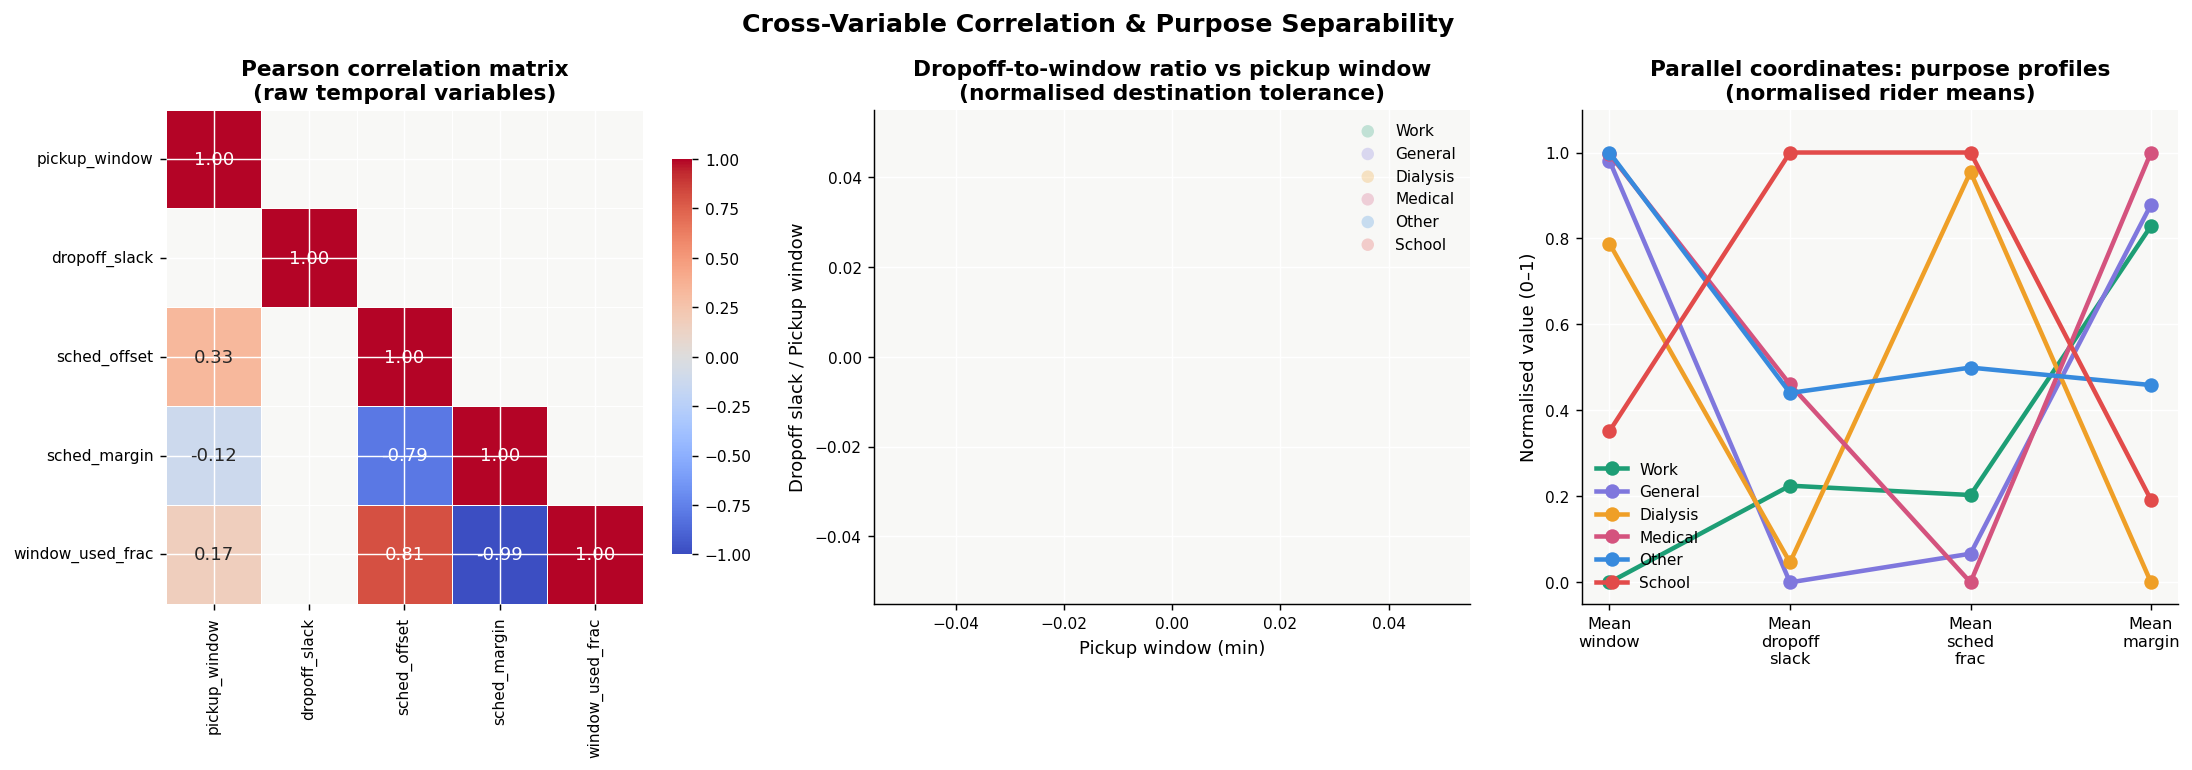

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Cross-Variable Correlation & Purpose Separability', fontsize=14, fontweight='bold')

# 1. Correlation matrix of raw temporal variables
ax = axes[0]
raw_cols = ['pickup_window','dropoff_slack','sched_offset','sched_margin','window_used_frac']
corr_mat = dc[raw_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=ax, cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, mask=mask,
            cbar_kws={'shrink':0.8})
ax.set_title('Pearson correlation matrix\n(raw temporal variables)')

# 2. Pairplot summary: pickup_window vs dropoff_slack vs window_used_frac
ax = axes[1]
for p in PURPOSE_ORDER:
    sub = dc[dc['Purpose']==p]
    ax.scatter(sub['pickup_window'], sub['dropoff_slack'] / (sub['pickup_window']+1),
               color=PALETTE[p], alpha=0.25, s=12, label=p, edgecolors='none')
ax.set_title('Dropoff-to-window ratio vs pickup window\n(normalised destination tolerance)')
ax.set_xlabel('Pickup window (min)')
ax.set_ylabel('Dropoff slack / Pickup window')
ax.legend(frameon=False, markerscale=2)

# 3. Parallel coordinates: mean rider metrics per purpose
ax = axes[2]
from sklearn.preprocessing import MinMaxScaler as MMS
pc_cols = ['mean_window','mean_do_slack','mean_sched_frac','mean_sched_margin']
pc_labels = ['Mean\nwindow','Mean\ndropoff\nslack','Mean\nsched\nfrac','Mean\nmargin']
pc_data = rider_raw.groupby('dom_purpose')[pc_cols].mean().reindex(PURPOSE_ORDER)
pc_norm = pd.DataFrame(MMS().fit_transform(pc_data), columns=pc_cols, index=pc_data.index)

for p in PURPOSE_ORDER:
    ax.plot(range(len(pc_cols)), pc_norm.loc[p], color=PALETTE[p],
            linewidth=2.5, marker='o', markersize=7, label=p)
ax.set_xticks(range(len(pc_cols)))
ax.set_xticklabels(pc_labels, fontsize=9)
ax.set_title('Parallel coordinates: purpose profiles\n(normalised rider means)')
ax.set_ylabel('Normalised value (0–1)'); ax.set_ylim(-0.05, 1.1)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('eda_fig7_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print('=' * 65)
print('TABLE 1 — PICKUP WINDOW STATISTICS BY PURPOSE')
print('=' * 65)
display(dc.groupby('Purpose')['pickup_window'].describe().round(1).reindex(PURPOSE_ORDER))

print('\n' + '=' * 65)
print('TABLE 2 — DROPOFF SLACK STATISTICS BY PURPOSE')
print('=' * 65)
display(dc.groupby('Purpose')['dropoff_slack'].describe().round(1).reindex(PURPOSE_ORDER))

print('\n' + '=' * 65)
print('TABLE 3 — SCHEDULING POSITION BY PURPOSE')
print('=' * 65)
display(dc.groupby('Purpose')['window_used_frac'].describe().round(3).reindex(PURPOSE_ORDER))

print('\n' + '=' * 65)
print('TABLE 4 — STATISTICAL TESTS (PURPOSE SEPARABILITY)')
print('=' * 65)
for col, label in [('pickup_window','Pickup window'),
                    ('dropoff_slack','Dropoff slack'),
                    ('window_used_frac','Sched position')]:
    groups = [dc[dc['Purpose']==p][col].dropna().values for p in PURPOSE_ORDER]
    H, p  = kruskal(*groups)
    print(f'{label:<22}: Kruskal-Wallis H={H:.2f}, p={p:.2e}')

print('\n' + '=' * 65)
print('TABLE 5 — FLEET-LEVEL HEADLINE NUMBERS')
print('=' * 65)
print(f'Total trips              : {len(df):,}')
print(f'Completed trips          : {len(dc):,}  ({len(dc)/len(df)*100:.1f}%)')
print(f'Unique riders            : {df["Customer Number"].nunique()}')
print(f'Median pickup window     : {dc["pickup_window"].median():.0f} min')
print(f'Mean pickup window       : {dc["pickup_window"].mean():.1f} min  (SD={dc["pickup_window"].std():.1f})')
print(f'Median dropoff slack     : {dc["dropoff_slack"].median():.0f} min')
print(f'Mean sched position      : {dc["window_used_frac"].mean():.3f}  (0=earliest, 1=latest)')
print(f'Mean unused margin       : {dc["sched_margin"].mean():.1f} min')
print(f'Overall cancel rate      : {(df["Trip Status"]=="Cancelled").mean()*100:.1f}%')
print(f'Overall no-show rate     : {(df["Trip Status"]=="No-Show").mean()*100:.1f}%')
print()
print('Purpose with narrowest window : dialysis')
print('Purpose with widest window    : general')
for p in PURPOSE_ORDER:
    mw = dc[dc['Purpose']==p]['pickup_window'].median()
    ms = dc[dc['Purpose']==p]['dropoff_slack'].median()
    print(f'  {p:<12}: median window={mw:.0f}min  median dropoff slack={ms:.0f}min')

In [17]:


# ── Cancellation subset ──────────────────────────────────────────
# All trips with a Cancel Type (non-null)
dcan = df[df['Cancel Type'].notna()].copy()

# ── Cancel lead time: minutes from cancel to scheduled pickup ────
# Cancel Time column format: same datetime as Scheduled ('6/29/23 5:28')
def t2m(t):
    if pd.isna(t) or str(t).strip() in ('','nan','NaT'):
        return np.nan
    s = str(t).strip()
    if ' ' in s:
        try:
            dt = pd.to_datetime(s, dayfirst=False)
            return dt.hour * 60 + dt.minute
        except:
            return np.nan
    try:
        h, m = s.split(':')[:2]
        return int(h)*60 + int(m)
    except:
        return np.nan

dcan['cancel_min']  = dcan['Cancel Time'].apply(t2m)
dcan['sched_min']   = dcan['Scheduled Pick-up Arrival Time'].apply(t2m)
dcan['req_min']     = dcan['Requested Drop-off Time'].apply(t2m)
dcan['early_min']   = dcan['Earliest Pick-up'].apply(t2m)

# Lead time: positive = cancelled before scheduled pickup
dcan['cancel_lead_min'] = dcan['sched_min'] - dcan['cancel_min']
# Clip extreme outliers (same-day only: -120 to +480 min)
dcan['cancel_lead_clipped'] = dcan['cancel_lead_min'].clip(-120, 480)

# Requested pickup hour
dcan['req_hour'] = (dcan['early_min'] // 60).astype('Int64')

# Day of week
dcan['dow'] = dcan['Trip Date'].dt.day_name()

# Time bin
dcan['time_bin'] = pd.cut(
    dcan['early_min'],
    bins=[0,360,480,600,720,840,960,1440],
    labels=['<6am','6-8am','8-10am','10am-12pm','12-2pm','2-4pm','4pm+']
)

# Cancel type ordering by urgency
CANCEL_ORDER = [
    'Advanced Cancel','IVR','Self Service',
    'Modified','Trip correction','Renegotiation',
    'Late Cancel','User Error Cancel','Cancel At Door',
    'Refusal','Denial','No show','Site closure'
]
# Keep only types present in data
CANCEL_ORDER = [c for c in CANCEL_ORDER if c in dcan['Cancel Type'].unique()]
# Assign colors
_cancel_palette = [
    '#1D9E75','#5DCAA5','#9FE1CB',
    '#7F77DD','#AFA9EC','#534AB7',
    '#EF9F27','#BA7517','#854F0B',
    '#E24B4A','#D85A30','#A32D2D','#888780'
]
CANCEL_PALETTE = {c: _cancel_palette[i % len(_cancel_palette)]
                   for i, c in enumerate(CANCEL_ORDER)}

print(f'Cancellation rows  : {len(dcan):,}')
print(f'Cancel types found : {dcan["Cancel Type"].nunique()}')
print(f'Lead time available: {dcan["cancel_lead_min"].notna().sum():,} rows')
print('\n── Cancel type counts ──────────────────────────────────────')
display(dcan['Cancel Type'].value_counts().rename('count').to_frame())

Cancellation rows  : 53,304
Cancel types found : 13
Lead time available: 10,715 rows

── Cancel type counts ──────────────────────────────────────


,count
Advanced Cancel,20518
Modified,14476
Trip correction,8477
No show,7488
IVR,1027
Late Cancel,630
Refusal,217
Denial,175
Cancel At Door,148
User Error Cancel,65


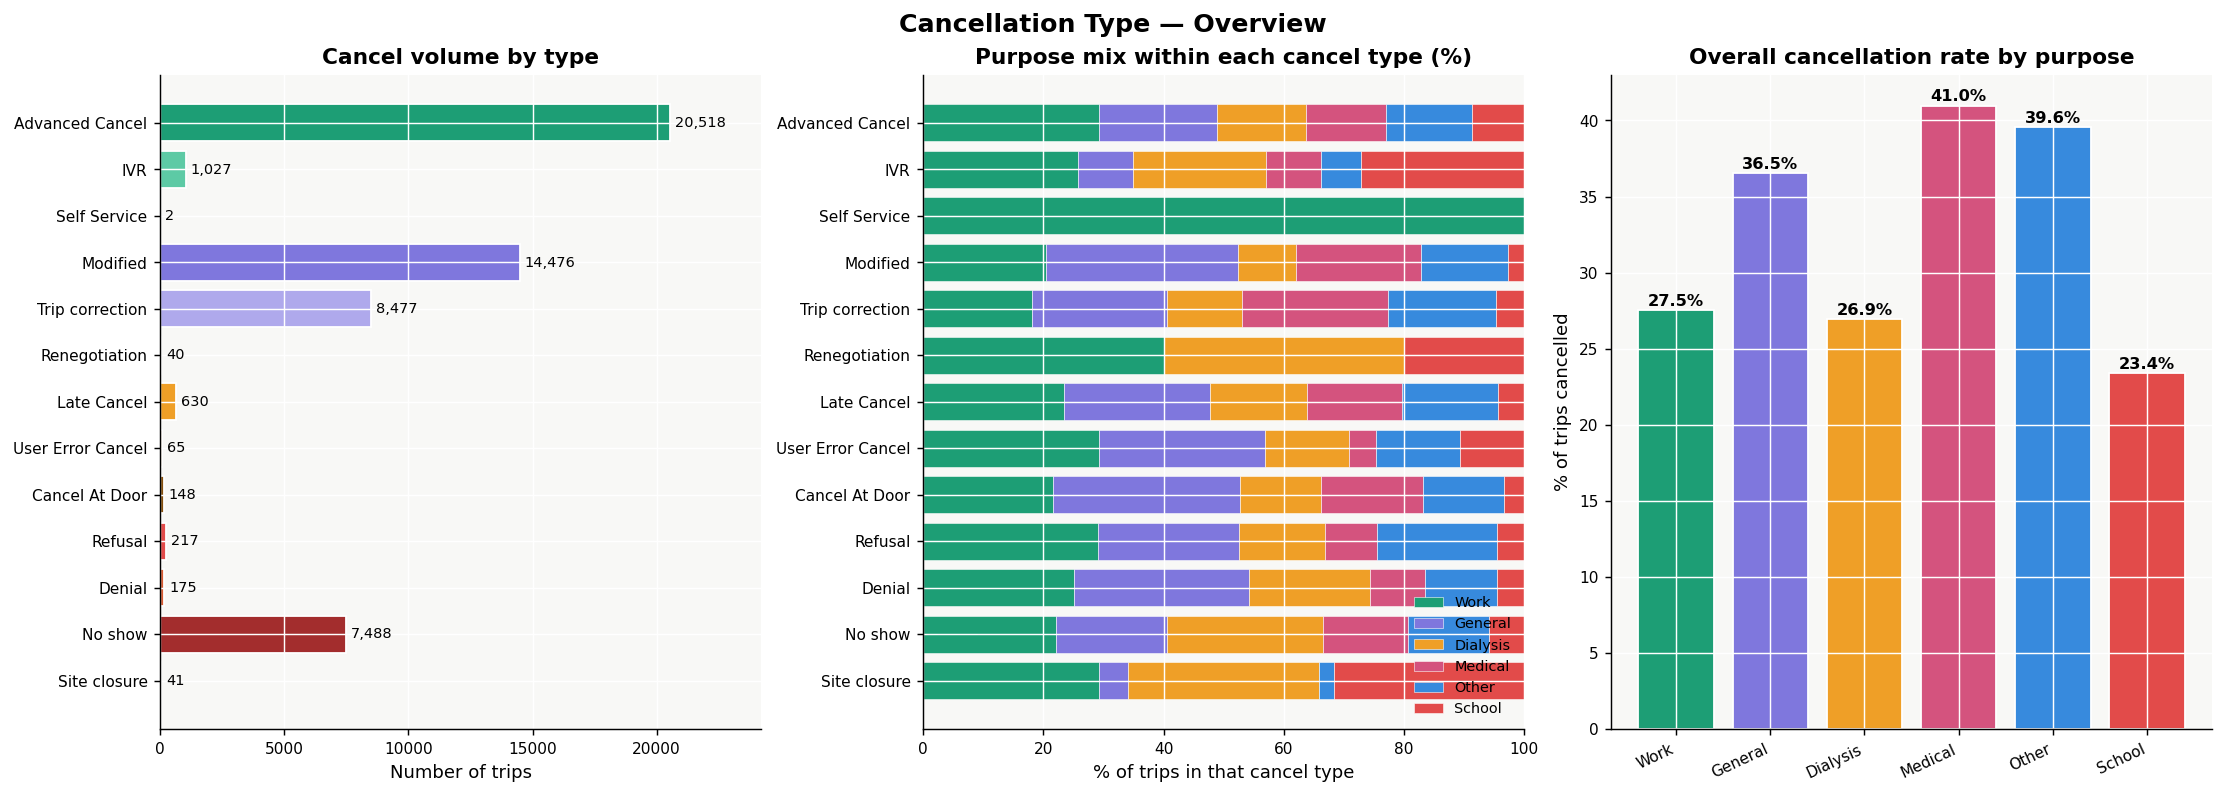

In [18]:
#%%
fig, axes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
fig.suptitle('Cancellation Type — Overview', fontsize=14, fontweight='bold')

# 1. Horizontal bar — volume
ax = axes[0]
ct_counts = dcan['Cancel Type'].value_counts().reindex(CANCEL_ORDER).dropna()
bars = ax.barh(ct_counts.index[::-1], ct_counts.values[::-1],
               color=[CANCEL_PALETTE.get(c,'#888') for c in ct_counts.index[::-1]],
               edgecolor='white')
for bar, val in zip(bars, ct_counts.values[::-1]):
    ax.text(bar.get_width() + ct_counts.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=8)
ax.set_title('Cancel volume by type')
ax.set_xlabel('Number of trips')
ax.set_xlim(0, ct_counts.max()*1.18)

# 2. % of all trips by cancel type × purpose
ax = axes[1]
ct_purp = pd.crosstab(dcan['Cancel Type'], dcan['Purpose'],
                        normalize='index') * 100
ct_purp = ct_purp.reindex(CANCEL_ORDER).dropna(how='all')
avail_p = [p for p in PURPOSE_ORDER if p in ct_purp.columns]
bottom = np.zeros(len(ct_purp))
for p in avail_p:
    vals = ct_purp[p].fillna(0).values
    ax.barh(ct_purp.index[::-1], vals[::-1], left=bottom[::-1],
            color=PALETTE.get(p,'#888'), label=p, edgecolor='white', linewidth=0.3)
    bottom += vals
ax.set_title('Purpose mix within each cancel type (%)')
ax.set_xlabel('% of trips in that cancel type')
ax.legend(frameon=False, fontsize=8, loc='lower right')

# 3. Cancel rate by purpose (% of that purpose's trips that were cancelled)
ax = axes[2]
total_by_purp = df.groupby('Purpose').size()
cancel_by_purp = dcan.groupby('Purpose').size()
cancel_rate = (cancel_by_purp / total_by_purp * 100).reindex(avail_p).dropna()
bars2 = ax.bar(cancel_rate.index, cancel_rate.values,
               color=[PALETTE.get(p,'#888') for p in cancel_rate.index],
               edgecolor='white')
for bar, val in zip(bars2, cancel_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Overall cancellation rate by purpose')
ax.set_ylabel('% of trips cancelled')
ax.set_xticklabels(cancel_rate.index, rotation=25, ha='right')

plt.savefig('ca_fig1_overview.png', bbox_inches='tight', dpi=150)
plt.show()

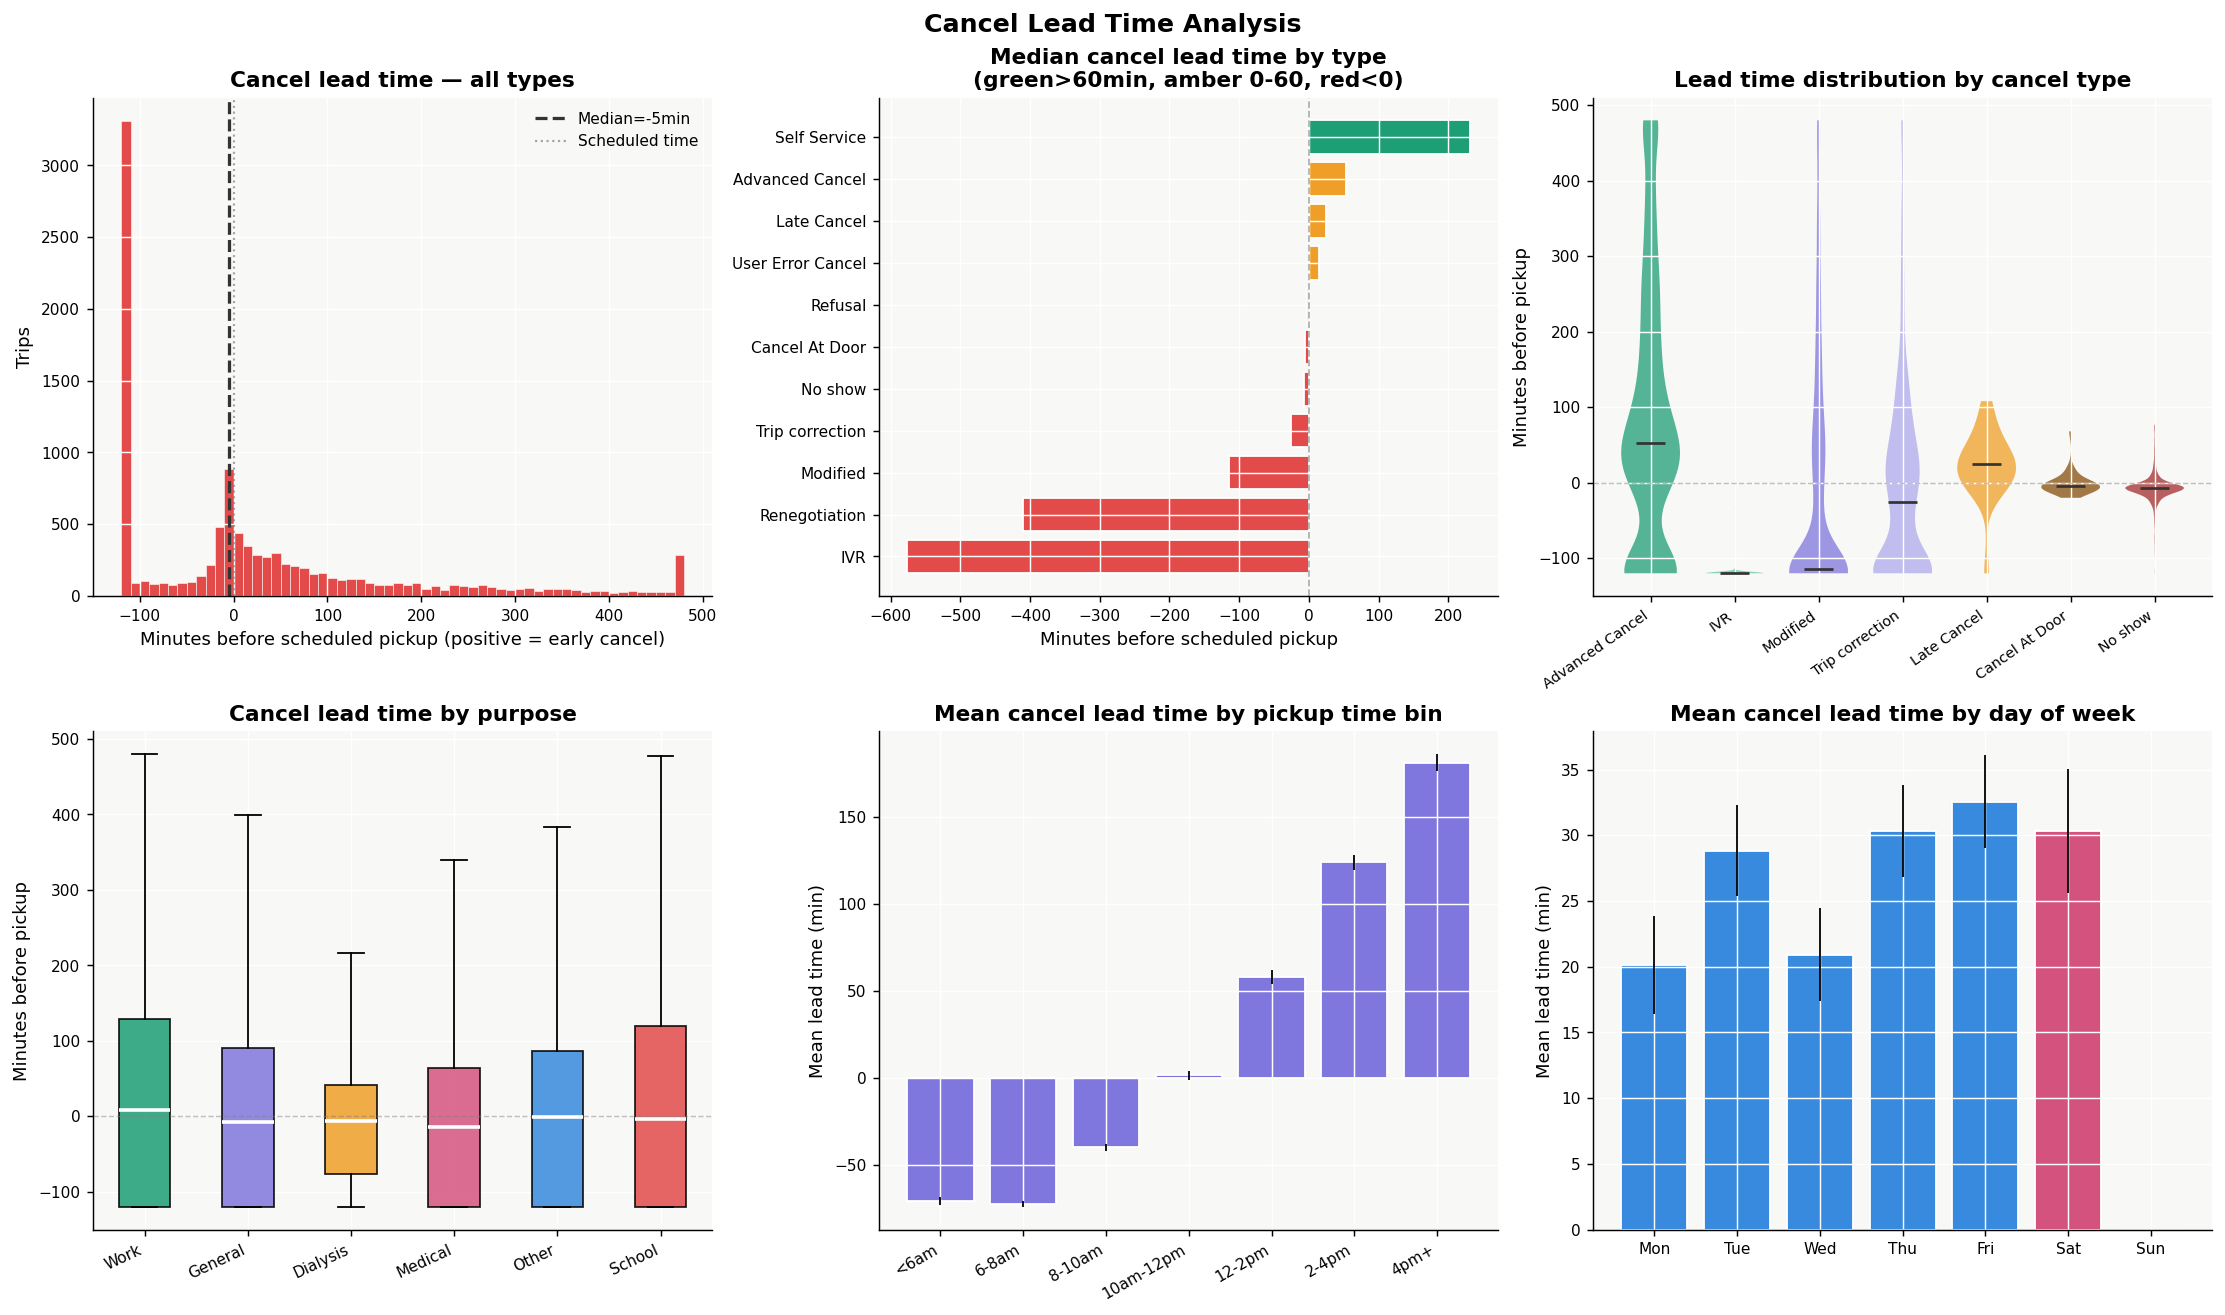


── Lead time summary by cancel type (minutes) ──────────────


,count,mean,std,min,25%,50%,75%,90%,max
Cancel Type,,,,,,,,,
Advanced Cancel,3972.0,44.3,266.0,-821.0,-44.2,53.0,195.0,369.0,842.0
IVR,229.0,-584.2,238.2,-978.0,-821.0,-576.0,-373.0,-243.0,-33.0
Self Service,2.0,231.5,318.9,6.0,118.8,231.5,344.2,411.9,457.0
Modified,3241.0,-119.5,278.4,-783.0,-334.0,-114.0,68.0,247.0,797.0
Trip correction,1643.0,-82.6,238.7,-765.0,-245.0,-25.0,56.0,145.0,753.0
Renegotiation,7.0,-410.0,0.0,-410.0,-410.0,-410.0,-410.0,-410.0,-410.0
Late Cancel,20.0,21.4,52.1,-154.0,5.0,25.0,40.8,79.4,108.0
User Error Cancel,3.0,13.0,1.7,11.0,12.5,14.0,14.0,14.0,14.0
Cancel At Door,30.0,-1.3,15.6,-20.0,-8.0,-5.0,-0.2,14.1,68.0


In [19]:
#%%
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
fig.suptitle('Cancel Lead Time Analysis', fontsize=14, fontweight='bold')

lead_valid = dcan[dcan['cancel_lead_min'].notna()]

# 1. Overall lead time histogram
ax = axes[0, 0]
lead_cl = lead_valid['cancel_lead_clipped']
ax.hist(lead_cl, bins=60, color='#E24B4A', edgecolor='white', linewidth=0.3)
ax.axvline(lead_cl.median(), color='#333', lw=1.8, ls='--',
           label=f'Median={lead_cl.median():.0f}min')
ax.axvline(0, color='gray', lw=1.2, ls=':', alpha=0.7, label='Scheduled time')
ax.set_title('Cancel lead time — all types')
ax.set_xlabel('Minutes before scheduled pickup (positive = early cancel)')
ax.set_ylabel('Trips')
ax.legend(frameon=False)

# 2. Median lead time by cancel type
ax = axes[0, 1]
lead_by_type = (lead_valid.groupby('Cancel Type')['cancel_lead_min']
                  .median()
                  .reindex(CANCEL_ORDER)
                  .dropna()
                  .sort_values())
colors_lt = ['#1D9E75' if v > 60 else '#EF9F27' if v > 0 else '#E24B4A'
              for v in lead_by_type.values]
ax.barh(lead_by_type.index, lead_by_type.values, color=colors_lt, edgecolor='white')
ax.axvline(0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_title('Median cancel lead time by type\n(green>60min, amber 0-60, red<0)')
ax.set_xlabel('Minutes before scheduled pickup')

# 3. Lead time distribution by cancel type — violin
ax = axes[0, 2]
vdata  = []
vlabels = []
for c in CANCEL_ORDER:
    sub = lead_valid[lead_valid['Cancel Type']==c]['cancel_lead_clipped'].dropna()
    if len(sub) > 10:
        vdata.append(sub.values)
        vlabels.append(c)
if vdata:
    parts = ax.violinplot(vdata, positions=range(len(vdata)),
                           showmedians=True, showextrema=False, widths=0.7)
    for body, c in zip(parts['bodies'], vlabels):
        body.set_facecolor(CANCEL_PALETTE.get(c,'#888'))
        body.set_alpha(0.75)
    parts['cmedians'].set_color('#333')
    ax.set_xticks(range(len(vlabels)))
    ax.set_xticklabels(vlabels, rotation=35, ha='right', fontsize=8)
    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Lead time distribution by cancel type')
ax.set_ylabel('Minutes before pickup')

# 4. Lead time by purpose (boxplot)
ax = axes[1, 0]
bp = ax.boxplot(
    [lead_valid[lead_valid['Purpose']==p]['cancel_lead_clipped'].dropna().values
     for p in avail_p],
    labels=avail_p, patch_artist=True, showfliers=False,
    medianprops={'color':'white','linewidth':2}
)
for patch, p in zip(bp['boxes'], avail_p):
    patch.set_facecolor(PALETTE.get(p,'#888')); patch.set_alpha(0.85)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Cancel lead time by purpose')
ax.set_ylabel('Minutes before pickup')
ax.set_xticklabels(avail_p, rotation=25, ha='right')

# 5. Lead time by time of day
ax = axes[1, 1]
tbin_lead = (lead_valid.groupby('time_bin', observed=True)['cancel_lead_clipped']
               .agg(['mean','sem'])
               .dropna())
ax.bar(tbin_lead.index, tbin_lead['mean'],
       yerr=tbin_lead['sem'].fillna(0),
       color='#7F77DD', edgecolor='white',
       error_kw={'linewidth':1,'color':'#555'})
ax.set_title('Mean cancel lead time by pickup time bin')
ax.set_ylabel('Mean lead time (min)')
ax.set_xticklabels(tbin_lead.index, rotation=30, ha='right')

# 6. Lead time by day of week
ax = axes[1, 2]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_lead = (lead_valid.groupby('dow')['cancel_lead_clipped']
              .agg(['mean','sem'])
              .reindex(dow_order))
colors_dow = ['#378ADD']*5 + ['#D4537E']*2
ax.bar(range(7), dow_lead['mean'].fillna(0),
       yerr=dow_lead['sem'].fillna(0),
       color=colors_dow, edgecolor='white',
       error_kw={'linewidth':1,'color':'#555'})
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_title('Mean cancel lead time by day of week')
ax.set_ylabel('Mean lead time (min)')

plt.savefig('ca_fig2_lead_time.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n── Lead time summary by cancel type (minutes) ──────────────')
display(
    lead_valid.groupby('Cancel Type')['cancel_lead_min']
    .describe(percentiles=[0.25,0.5,0.75,0.9])
    .round(1)
    .reindex(CANCEL_ORDER)
    .dropna(how='all')
)

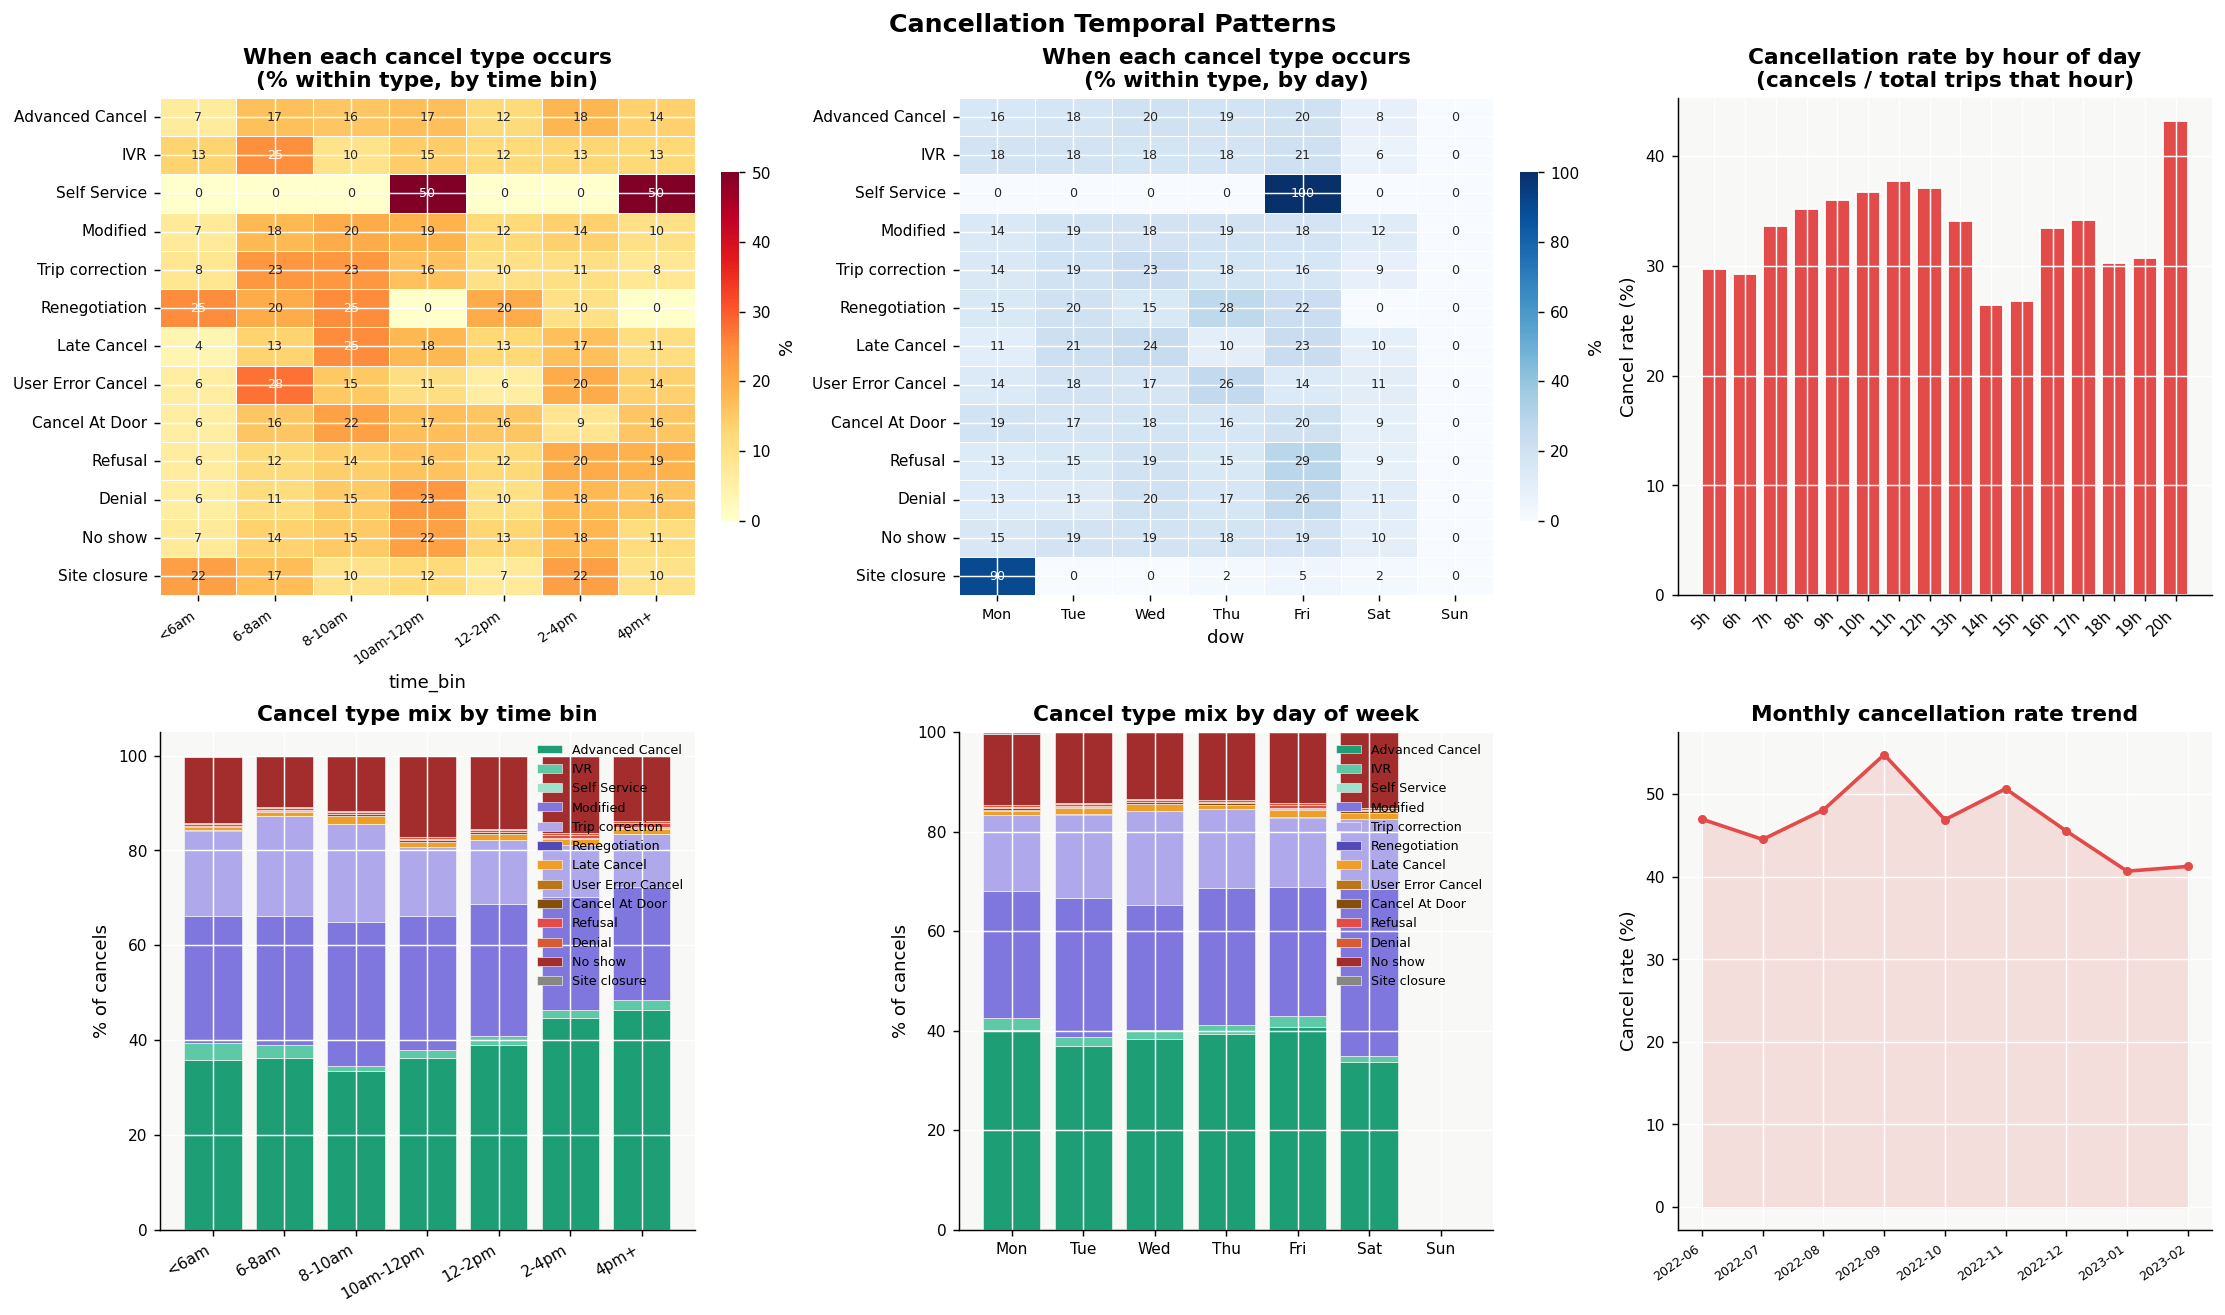

In [20]:
#%%
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
fig.suptitle('Cancellation Temporal Patterns', fontsize=14, fontweight='bold')

# 1. Cancel type by time bin (heatmap % within type)
ax = axes[0, 0]
ct_tbin = pd.crosstab(dcan['Cancel Type'], dcan['time_bin'],
                        normalize='index') * 100
ct_tbin = ct_tbin.reindex(CANCEL_ORDER).dropna(how='all')
sns.heatmap(ct_tbin, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'shrink':0.7,'label':'%'},
            annot_kws={'size':7})
ax.set_title('When each cancel type occurs\n(% within type, by time bin)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=7.5)
ax.set_ylabel('')

# 2. Cancel type by day of week (heatmap)
ax = axes[0, 1]
ct_dow = pd.crosstab(dcan['Cancel Type'], dcan['dow'],
                       normalize='index') * 100
ct_dow = ct_dow.reindex(CANCEL_ORDER).dropna(how='all')
ct_dow = ct_dow.reindex(columns=dow_order, fill_value=0)
sns.heatmap(ct_dow, ax=ax, cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'shrink':0.7,'label':'%'},
            annot_kws={'size':7})
ax.set_title('When each cancel type occurs\n(% within type, by day)')
ax.set_xticklabels([d[:3] for d in dow_order], rotation=0, fontsize=8)
ax.set_ylabel('')

# 3. Hourly cancel rate (cancels / total trips that hour)
ax = axes[0, 2]
total_by_hour = (df.dropna(subset=['pu_early'])
                   .assign(hr=(df['pu_early']//60).astype('Int64'))
                   .groupby('hr').size())
cancel_by_hour = (dcan.dropna(subset=['req_hour'])
                    .groupby('req_hour').size())
cancel_rate_hr = (cancel_by_hour / total_by_hour * 100).dropna()
cancel_rate_hr = cancel_rate_hr[
    (cancel_rate_hr.index >= 5) & (cancel_rate_hr.index <= 20)
]
x_hr = cancel_rate_hr.index.astype(float).to_numpy()
ax.bar(x_hr, cancel_rate_hr.values, color='#E24B4A',
       edgecolor='white', width=0.8)
ax.set_xticks(x_hr)
ax.set_xticklabels([f'{int(h)}h' for h in x_hr], rotation=45, ha='right')
ax.set_title('Cancellation rate by hour of day\n(cancels / total trips that hour)')
ax.set_ylabel('Cancel rate (%)')

# 4. Stacked bar: cancel type mix by time bin
ax = axes[1, 0]
ct_tbin2 = pd.crosstab(dcan['time_bin'], dcan['Cancel Type'])
ct_tbin2_pct = ct_tbin2.div(ct_tbin2.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ct_tbin2_pct))
for c in CANCEL_ORDER:
    if c in ct_tbin2_pct.columns:
        vals = ct_tbin2_pct[c].fillna(0).values
        ax.bar(ct_tbin2_pct.index, vals, bottom=bottom,
               color=CANCEL_PALETTE.get(c,'#888'), label=c,
               edgecolor='white', linewidth=0.3)
        bottom += vals
ax.set_title('Cancel type mix by time bin')
ax.set_ylabel('% of cancels')
ax.set_xticklabels(ct_tbin2_pct.index, rotation=30, ha='right')
ax.legend(frameon=False, fontsize=7, loc='upper right')

# 5. Stacked bar: cancel type mix by day of week
ax = axes[1, 1]
ct_dow2 = pd.crosstab(dcan['dow'], dcan['Cancel Type'])
ct_dow2 = ct_dow2.reindex(dow_order, fill_value=0)
ct_dow2_pct = ct_dow2.div(ct_dow2.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ct_dow2_pct))
for c in CANCEL_ORDER:
    if c in ct_dow2_pct.columns:
        vals = ct_dow2_pct[c].fillna(0).values
        ax.bar(range(7), vals, bottom=bottom,
               color=CANCEL_PALETTE.get(c,'#888'), label=c,
               edgecolor='white', linewidth=0.3)
        bottom += vals
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_title('Cancel type mix by day of week')
ax.set_ylabel('% of cancels')
ax.legend(frameon=False, fontsize=7, loc='upper right')

# 6. Monthly trend in cancellation rate
ax = axes[1, 2]
df['month'] = df['Trip Date'].dt.to_period('M').astype(str)
dcan['month'] = dcan['Trip Date'].dt.to_period('M').astype(str)
monthly_total  = df.groupby('month').size()
monthly_cancel = dcan.groupby('month').size()
monthly_rate   = (monthly_cancel / monthly_total * 100).dropna()
ax.plot(range(len(monthly_rate)), monthly_rate.values,
        color='#E24B4A', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(monthly_rate)), monthly_rate.values,
                alpha=0.15, color='#E24B4A')
step = max(1, len(monthly_rate)//8)
ax.set_xticks(range(0, len(monthly_rate), step))
ax.set_xticklabels(list(monthly_rate.index)[::step],
                    rotation=35, ha='right', fontsize=7)
ax.set_title('Monthly cancellation rate trend')
ax.set_ylabel('Cancel rate (%)')

plt.savefig('ca_fig3_temporal.png', bbox_inches='tight', dpi=150)
plt.show()

In [21]:
#%%
# Build rider-level cancel profile
rider_cancel = dcan.groupby('Customer Number').agg(
    n_cancels          = ('Trip ID',             'count'),
    n_advanced         = ('Cancel Type',         lambda x: (x=='Advanced Cancel').sum()),
    n_late             = ('Cancel Type',         lambda x: (x=='Late Cancel').sum()),
    n_noshow           = ('Cancel Type',         lambda x: (x=='No show').sum()),
    n_door             = ('Cancel Type',         lambda x: (x=='Cancel At Door').sum()),
    n_ivr              = ('Cancel Type',         lambda x: (x=='IVR').sum()),
    mean_lead          = ('cancel_lead_min',     'mean'),
    median_lead        = ('cancel_lead_min',     'median'),
    dom_cancel_type    = ('Cancel Type',         lambda x: x.mode().iloc[0] if len(x)>0 else np.nan),
    dom_purpose        = ('Purpose',             lambda x: x.mode().iloc[0] if len(x)>0 else np.nan),
).reset_index()

# Join with total trip count
total_trips = df.groupby('Customer Number').size().rename('total_trips')
rider_cancel = rider_cancel.merge(total_trips, on='Customer Number', how='left')
rider_cancel['cancel_rate']    = rider_cancel['n_cancels']   / rider_cancel['total_trips']
rider_cancel['advanced_rate']  = rider_cancel['n_advanced']  / rider_cancel['n_cancels']
rider_cancel['noshow_rate']    = rider_cancel['n_noshow']    / rider_cancel['n_cancels']
rider_cancel['late_rate']      = (rider_cancel['n_late'] + rider_cancel['n_door']) / rider_cancel['n_cancels']

# Flexibility score from cancellation behaviour:
# High advanced_rate + high mean_lead + low noshow_rate → flexible
from sklearn.preprocessing import MinMaxScaler
feat_cols = ['advanced_rate','mean_lead','noshow_rate']
rc_valid  = rider_cancel[feat_cols].fillna(0)
scaled    = MinMaxScaler().fit_transform(rc_valid)
# advanced_rate and mean_lead → high = flexible; noshow → invert
rider_cancel['cancel_flex_score'] = (
    0.4 * scaled[:,0] +   # advanced_rate
    0.4 * scaled[:,1] +   # mean_lead
    0.2 * (1 - scaled[:,2])  # 1 - noshow_rate
)

print('── Rider-level cancel stats ────────────────────────────────')
display(rider_cancel[[
    'n_cancels','total_trips','cancel_rate',
    'advanced_rate','noshow_rate','late_rate',
    'mean_lead','cancel_flex_score'
]].describe().round(3))

── Rider-level cancel stats ────────────────────────────────


,n_cancels,total_trips,cancel_rate,advanced_rate,noshow_rate,late_rate,mean_lead,cancel_flex_score
count,910.000,910.000,910.000,910.000,910.000,910.000,620.000,910.000
mean,58.576,177.038,0.453,0.364,0.169,0.014,-38.910,0.552
std,78.325,222.330,0.249,0.232,0.201,0.048,140.641,0.124
min,1.000,1.000,0.006,0.000,0.000,0.000,-743.900,0.227
25%,8.000,19.000,0.265,0.201,0.030,0.000,-105.018,0.471
50%,29.000,73.500,0.412,0.345,0.109,0.000,-14.143,0.548
75%,75.750,269.250,0.600,0.500,0.228,0.014,53.174,0.624
max,657.000,1355.000,1.000,1.000,1.000,1.000,449.500,0.881


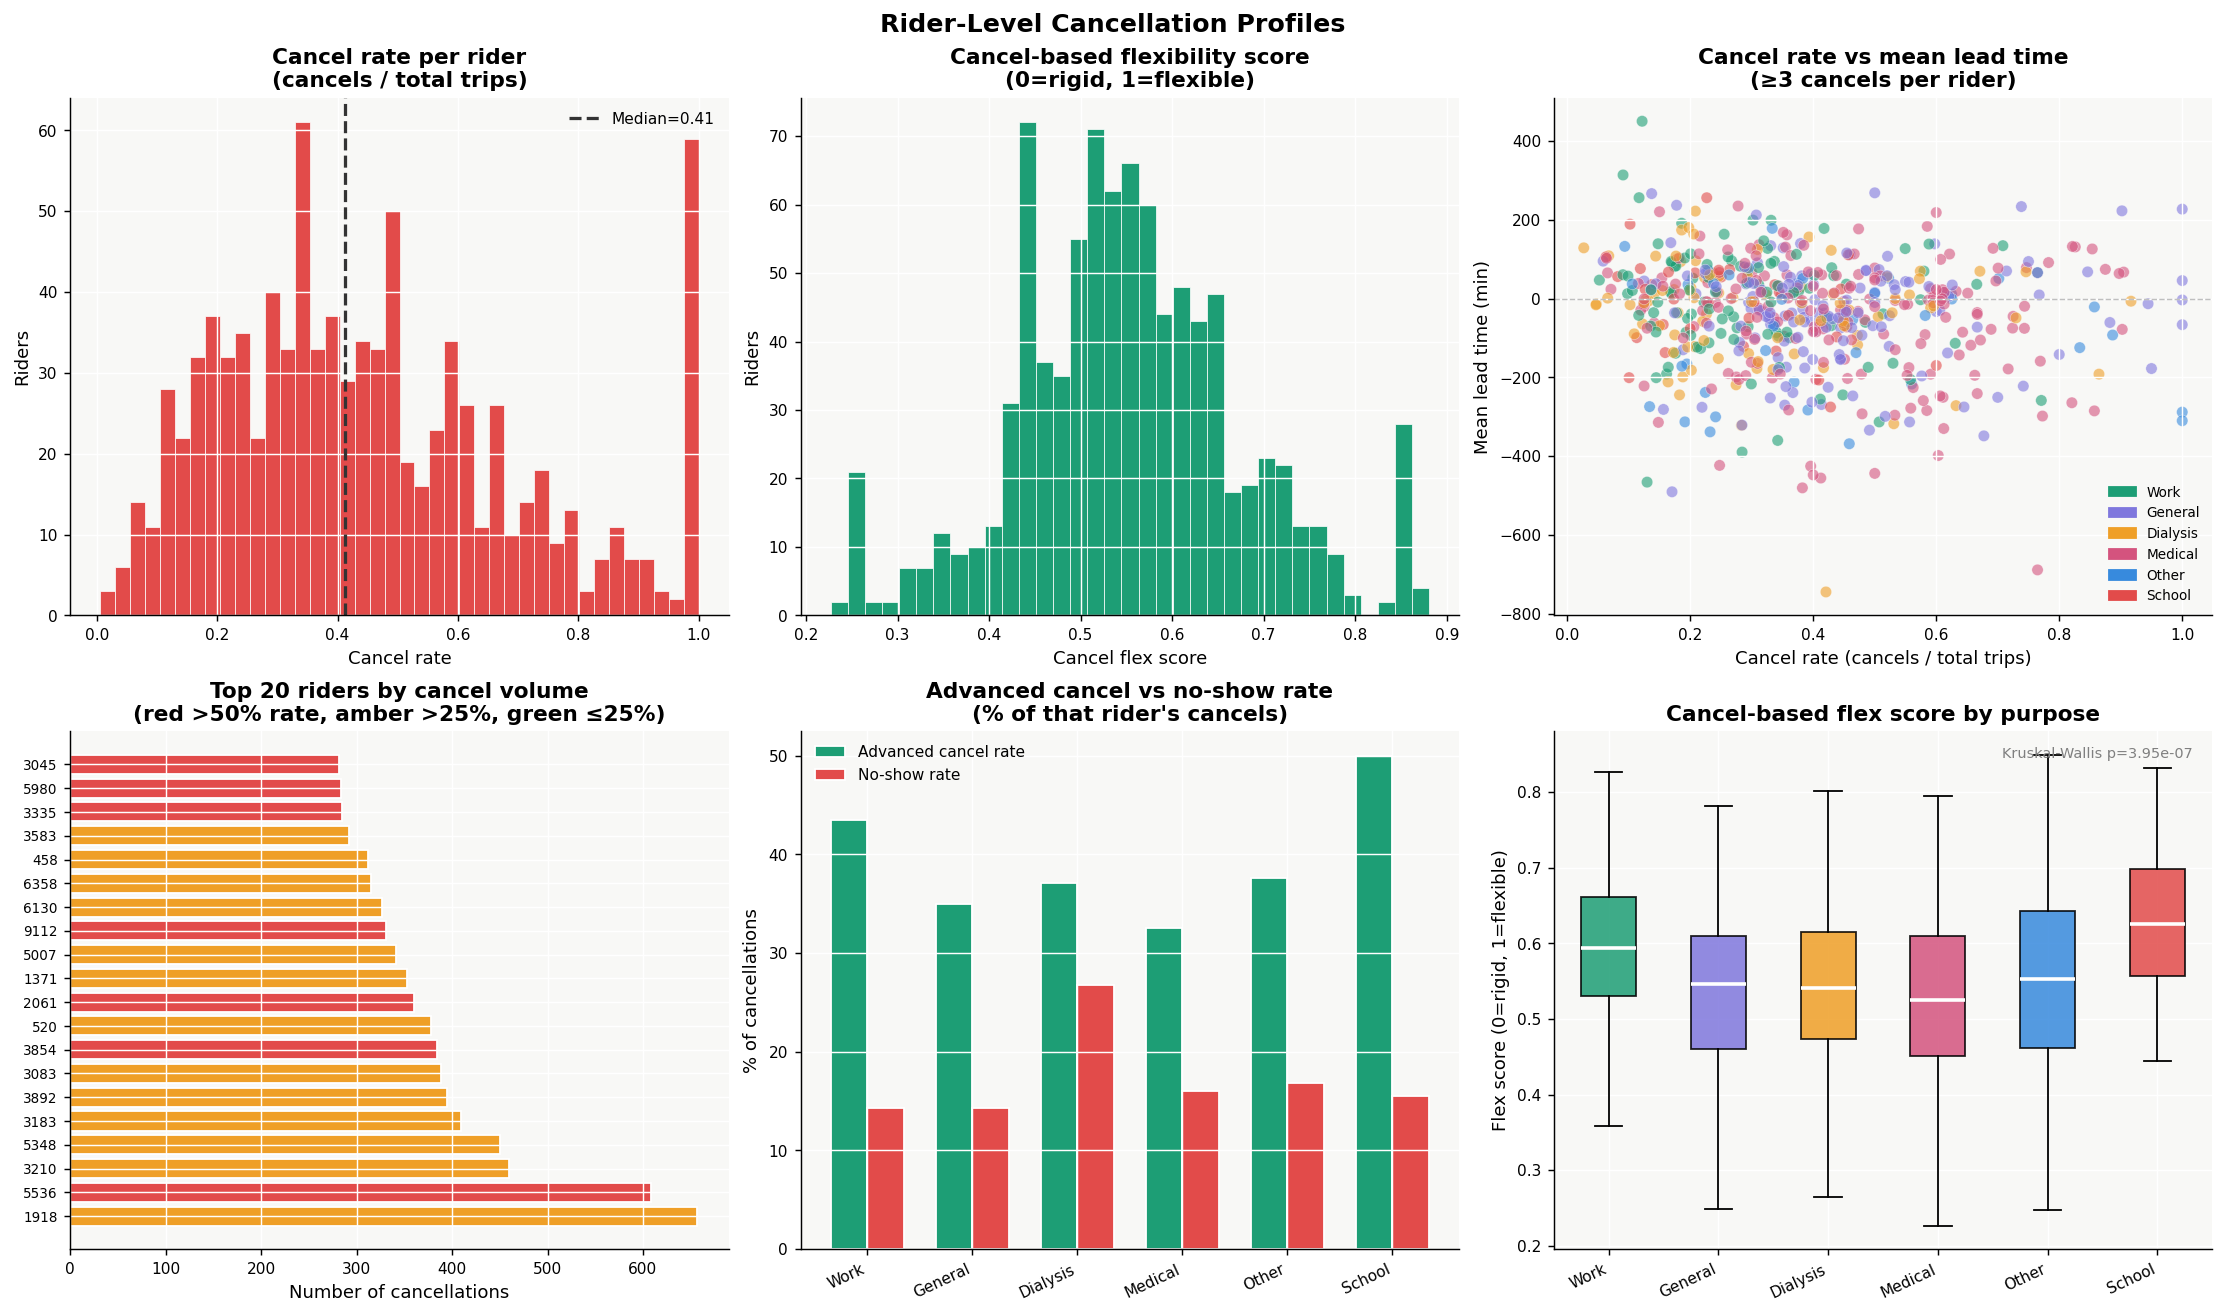

In [22]:
#%%
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
fig.suptitle('Rider-Level Cancellation Profiles', fontsize=14, fontweight='bold')

# 1. Cancel rate distribution
ax = axes[0, 0]
ax.hist(rider_cancel['cancel_rate'].dropna(), bins=40,
        color='#E24B4A', edgecolor='white', linewidth=0.4)
ax.axvline(rider_cancel['cancel_rate'].median(), color='#333',
           lw=1.8, ls='--',
           label=f"Median={rider_cancel['cancel_rate'].median():.2f}")
ax.set_title('Cancel rate per rider\n(cancels / total trips)')
ax.set_xlabel('Cancel rate'); ax.set_ylabel('Riders')
ax.legend(frameon=False)

# 2. Cancel flex score distribution
ax = axes[0, 1]
ax.hist(rider_cancel['cancel_flex_score'].dropna(), bins=35,
        color='#1D9E75', edgecolor='white', linewidth=0.4)
ax.set_title('Cancel-based flexibility score\n(0=rigid, 1=flexible)')
ax.set_xlabel('Cancel flex score'); ax.set_ylabel('Riders')

# 3. Mean lead time vs cancel rate scatter
ax = axes[0, 2]
rc_plot = rider_cancel[rider_cancel['n_cancels'] >= 3]
sc = ax.scatter(
    rc_plot['cancel_rate'],
    rc_plot['mean_lead'],
    c=[PALETTE.get(p,'#888') for p in rc_plot['dom_purpose'].fillna('general')],
    alpha=0.6, s=40, edgecolors='white', linewidth=0.3
)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Cancel rate vs mean lead time\n(≥3 cancels per rider)')
ax.set_xlabel('Cancel rate (cancels / total trips)')
ax.set_ylabel('Mean lead time (min)')
patches = [mpatches.Patch(color=PALETTE.get(p,'#888'), label=p) for p in avail_p]
ax.legend(handles=patches, frameon=False, fontsize=7.5)

# 4. Top 20 riders by cancel volume
ax = axes[1, 0]
top20 = rider_cancel.nlargest(20, 'n_cancels')
colors_top = ['#E24B4A' if r > 0.5 else '#EF9F27' if r > 0.25 else '#1D9E75'
               for r in top20['cancel_rate']]
ax.barh(range(20), top20['n_cancels'].values, color=colors_top, edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels(top20['Customer Number'].values, fontsize=7.5)
ax.set_title('Top 20 riders by cancel volume\n(red >50% rate, amber >25%, green ≤25%)')
ax.set_xlabel('Number of cancellations')

# 5. Advanced cancel rate by purpose
ax = axes[1, 1]
adv_by_purp = rider_cancel.groupby('dom_purpose')['advanced_rate'].mean().reindex(avail_p).dropna()
ns_by_purp  = rider_cancel.groupby('dom_purpose')['noshow_rate'].mean().reindex(avail_p).dropna()
x = np.arange(len(avail_p)); w = 0.35
ax.bar(x - w/2, adv_by_purp.reindex(avail_p).fillna(0)*100, w,
       color='#1D9E75', label='Advanced cancel rate', edgecolor='white')
ax.bar(x + w/2, ns_by_purp.reindex(avail_p).fillna(0)*100, w,
       color='#E24B4A', label='No-show rate', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(avail_p, rotation=25, ha='right')
ax.set_title('Advanced cancel vs no-show rate\n(% of that rider\'s cancels)')
ax.set_ylabel('% of cancellations')
ax.legend(frameon=False)

# 6. Cancel flex score by dominant purpose
ax = axes[1, 2]
bp = ax.boxplot(
    [rider_cancel[rider_cancel['dom_purpose']==p]['cancel_flex_score'].dropna().values
     for p in avail_p],
    labels=avail_p, patch_artist=True, showfliers=False,
    medianprops={'color':'white','linewidth':2}
)
for patch, p in zip(bp['boxes'], avail_p):
    patch.set_facecolor(PALETTE.get(p,'#888')); patch.set_alpha(0.85)
ax.set_title('Cancel-based flex score by purpose')
ax.set_ylabel('Flex score (0=rigid, 1=flexible)')
ax.set_xticklabels(avail_p, rotation=25, ha='right')
if len(avail_p) >= 2:
    groups = [rider_cancel[rider_cancel['dom_purpose']==p]['cancel_flex_score'].dropna()
               for p in avail_p]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        H, pval = kruskal(*groups)
        ax.text(0.97, 0.97, f'Kruskal-Wallis p={pval:.2e}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='gray')

plt.savefig('ca_fig4_rider_profiles.png', bbox_inches='tight', dpi=150)
plt.show()

NameError: name 'chi2_contingency' is not defined

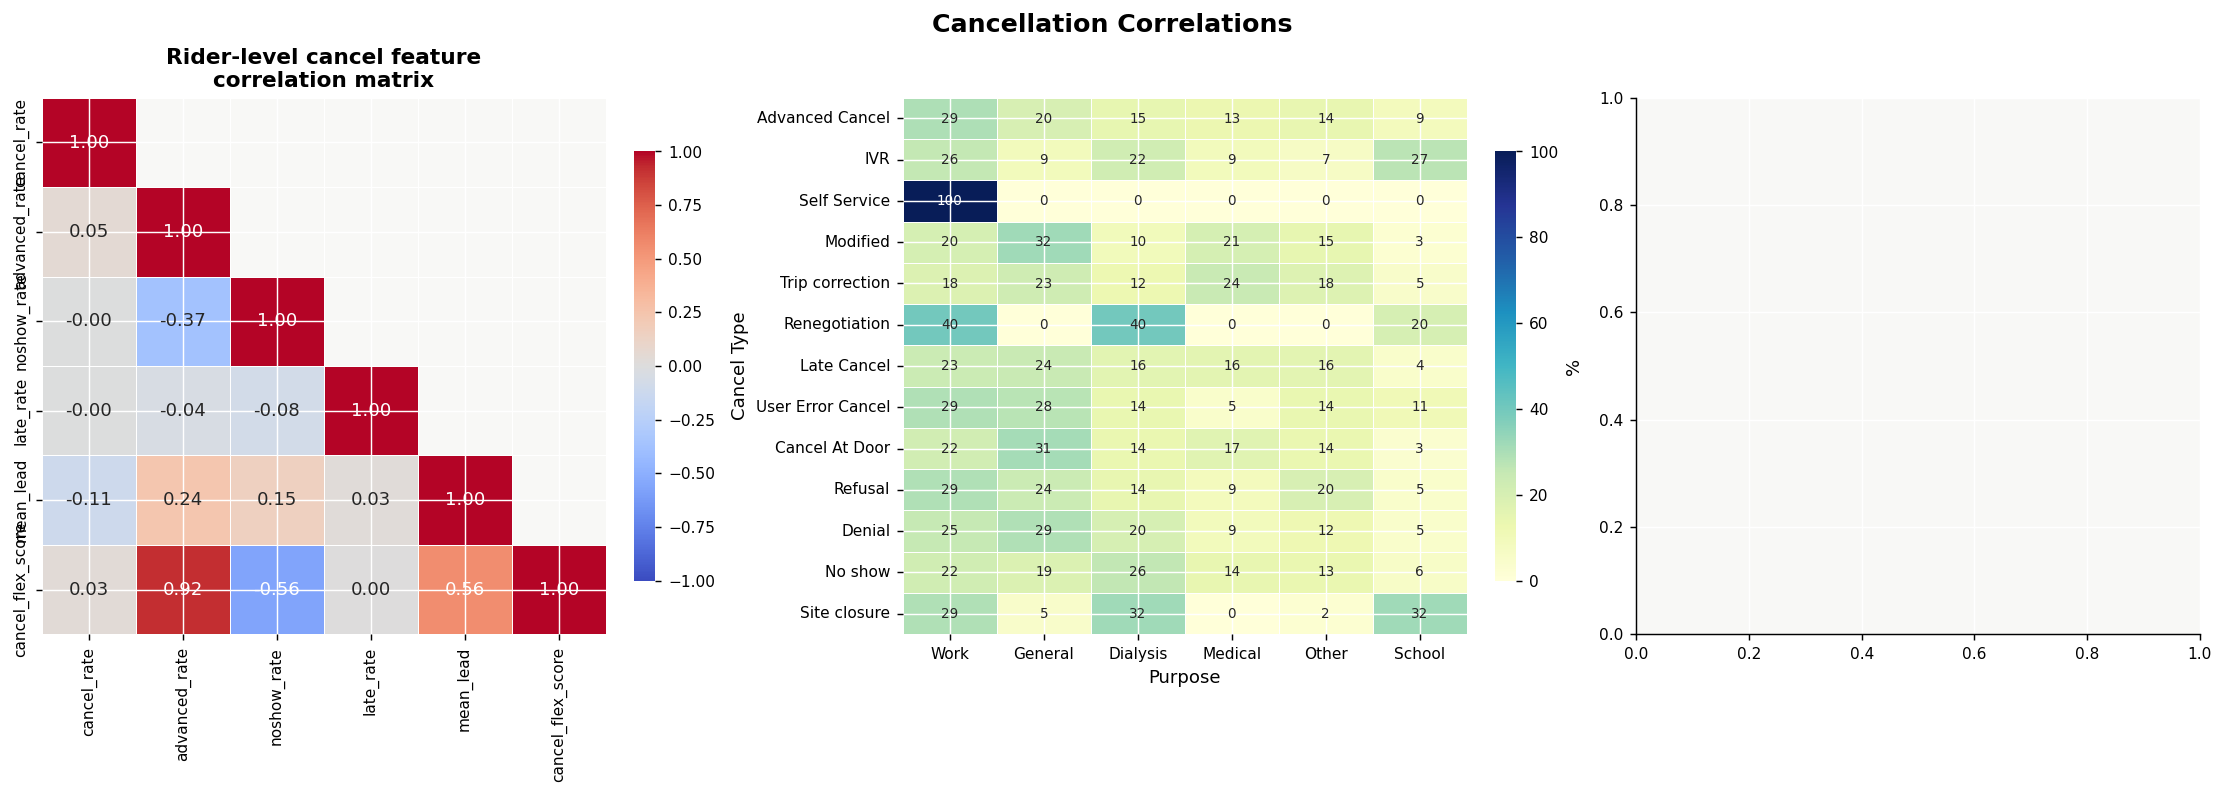

In [23]:
#%%
fig, axes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
fig.suptitle('Cancellation Correlations', fontsize=14, fontweight='bold')

# 1. Correlation matrix — rider-level cancel features
ax = axes[0]
corr_cols = ['cancel_rate','advanced_rate','noshow_rate',
              'late_rate','mean_lead','cancel_flex_score']
corr_mat = rider_cancel[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=ax, cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, mask=mask,
            cbar_kws={'shrink':0.8})
ax.set_title('Rider-level cancel feature\ncorrelation matrix')

# 2. Chi-square: cancel type × purpose
ax = axes[1]
ct_cross = pd.crosstab(dcan['Cancel Type'], dcan['Purpose'])
ct_cross = ct_cross.reindex(CANCEL_ORDER).dropna(how='all')
ct_pct = ct_cross.div(ct_cross.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct.reindex(columns=avail_p, fill_value=0),
            ax=ax, cmap='YlGnBu', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'shrink':0.8,'label':'%'},
            annot_kws={'size':7.5})
chi2, p, dof, _ = chi2_contingency(ct_cross.fillna(0))
ax.set_title(f'Cancel type × purpose (% within type)\nχ²={chi2:.0f}, p={p:.2e}, dof={dof}')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylabel('')

# 3. Requested pickup time vs cancel lead time scatter
ax = axes[2]
valid_sc = dcan[dcan['cancel_lead_min'].notna() & dcan['early_min'].notna()]
# Downsample for scatter (max 3000 pts)
if len(valid_sc) > 3000:
    valid_sc = valid_sc.sample(3000, random_state=42)
for ct in CANCEL_ORDER[:5]:   # top 5 types only for readability
    sub = valid_sc[valid_sc['Cancel Type']==ct]
    if len(sub) > 10:
        ax.scatter(sub['early_min']/60, sub['cancel_lead_clipped'],
                   color=CANCEL_PALETTE.get(ct,'#888'),
                   alpha=0.3, s=10, label=ct, edgecolors='none')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Requested pickup hour vs cancel lead time\n(top 5 cancel types)')
ax.set_xlabel('Requested pickup hour')
ax.set_ylabel('Cancel lead time (min)')
ax.legend(frameon=False, fontsize=7.5, markerscale=2)

plt.savefig('ca_fig5_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

# Statistical tests
print('── Chi-square: Cancel Type × Purpose ──────────────────────')
print(f'  χ² = {chi2:.1f},  p = {p:.2e},  dof = {dof}')
print('  Interpretation: p < 0.05 → cancel type and purpose are NOT independent')

print('\n── Kruskal-Wallis: lead time differs across cancel types? ───')
kw_groups = [dcan[dcan['Cancel Type']==c]['cancel_lead_min'].dropna().values
              for c in CANCEL_ORDER]
kw_groups = [g for g in kw_groups if len(g) > 5]
if len(kw_groups) >= 2:
    H, pval = kruskal(*kw_groups)
    print(f'  H = {H:.1f},  p = {pval:.2e}')

In [24]:
#%%
print('=' * 65)
print('TABLE 1 — CANCEL TYPE SUMMARY')
print('=' * 65)
display(
    dcan.groupby('Cancel Type').agg(
        N          = ('Trip ID',          'count'),
        pct        = ('Trip ID',          lambda x: len(x)/len(dcan)*100),
        median_lead= ('cancel_lead_min',  'median'),
        mean_lead  = ('cancel_lead_min',  'mean'),
    ).round(2).reindex(CANCEL_ORDER).dropna(how='all')
)

print('\n' + '=' * 65)
print('TABLE 2 — RIDER CANCEL PROFILE SUMMARY')
print('=' * 65)
display(
    rider_cancel[['cancel_rate','advanced_rate','noshow_rate',
                   'late_rate','mean_lead','cancel_flex_score']]
    .describe(percentiles=[0.25,0.5,0.75]).round(3)
)

print('\n' + '=' * 65)
print('TABLE 3 — CANCEL FLEX SCORE BY PURPOSE')
print('=' * 65)
display(
    rider_cancel.groupby('dom_purpose')['cancel_flex_score']
    .agg(['mean','std','median','count']).round(3)
    .reindex(avail_p)
)

print('\n' + '=' * 65)
print('HEADLINE NUMBERS')
print('=' * 65)
print(f"Total cancellations    : {len(dcan):,}")
print(f"Overall cancel rate    : {len(dcan)/len(df)*100:.1f}%")
print(f"Advanced cancel share  : {(dcan['Cancel Type']=='Advanced Cancel').mean()*100:.1f}%")
print(f"No-show share          : {(dcan['Cancel Type']=='No show').mean()*100:.1f}%")
print(f"Median cancel lead     : {dcan['cancel_lead_min'].median():.0f} min")
print(f"Mean cancel lead       : {dcan['cancel_lead_min'].mean():.0f} min")
print(f"Riders with ≥5 cancels : {(rider_cancel['n_cancels']>=5).sum()}")

TABLE 1 — CANCEL TYPE SUMMARY


,N,pct,median_lead,mean_lead
Cancel Type,,,,
Advanced Cancel,20518,38.49,53.0,44.26
IVR,1027,1.93,-576.0,-584.15
Self Service,2,0.00,231.5,231.50
Modified,14476,27.16,-114.0,-119.51
Trip correction,8477,15.90,-25.0,-82.60
Renegotiation,40,0.08,-410.0,-410.00
Late Cancel,630,1.18,25.0,21.45
User Error Cancel,65,0.12,14.0,13.00
Cancel At Door,148,0.28,-5.0,-1.27



TABLE 2 — RIDER CANCEL PROFILE SUMMARY


,cancel_rate,advanced_rate,noshow_rate,late_rate,mean_lead,cancel_flex_score
count,910.000,910.000,910.000,910.000,620.000,910.000
mean,0.453,0.364,0.169,0.014,-38.910,0.552
std,0.249,0.232,0.201,0.048,140.641,0.124
min,0.006,0.000,0.000,0.000,-743.900,0.227
25%,0.265,0.201,0.030,0.000,-105.018,0.471
50%,0.412,0.345,0.109,0.000,-14.143,0.548
75%,0.600,0.500,0.228,0.014,53.174,0.624
max,1.000,1.000,1.000,1.000,449.500,0.881



TABLE 3 — CANCEL FLEX SCORE BY PURPOSE


,mean,std,median,count
dom_purpose,,,,
Work,0.591,0.103,0.594,113
General,0.552,0.122,0.546,226
Dialysis,0.536,0.111,0.541,124
Medical,0.537,0.128,0.525,321
Other,0.552,0.143,0.553,85
School,0.615,0.115,0.625,41



HEADLINE NUMBERS
Total cancellations    : 53,304
Overall cancel rate    : 32.1%
Advanced cancel share  : 38.5%
No-show share          : 14.0%
Median cancel lead     : -5 min
Mean cancel lead       : -46 min
Riders with ≥5 cancels : 763
